# Metric Calculation — Combined Online Metrics (trained_models42 + trained_models43 + trained_models44)

Reproduces the online (streaming) decoder metrics — WER and SHREC'21 (Detection Rate,
Misclassification Rate, False Positive Rate, Jaccard Index, latency) — for both training
runs (`trained_models42`, `trained_models43`), all 4 users, both splits (test/val), using
the **default decoder configuration** (`bag_size=5`, `bg_exit_frames=1`,
`sign_bg_margin=0.10`, `confidence_threshold=0.35`, `min_sign_frames=15`) — i.e. this
reproduces the metrics each run originally produced, not an experimental variant.

Everything is self-contained in this notebook (decoder + metrics code copied in, not
imported from the project's `.py` files) — same convention as `visualize_decoder.ipynb`,
so it can be edited in place without touching the production sources.

Results are stored **per run, per user, per class** (raw counts, not just derived rates)
so any aggregate metric can be recomputed later from these tables without re-running the
decoder. For now the tables are just displayed inline — no file is written to disk yet.

---
## 1. Imports & Constants

In [1]:
from __future__ import annotations

import json
import os
from collections import Counter, deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ---------------------------------------------------------------------------
# Decoder constants — defaults only (must match config.py / decoder.py)
# ---------------------------------------------------------------------------
LEAP_FPS              = 30
BAG_SIZE               = 5
BAG_AGGREGATION        = "mean"
CONFIDENCE_THRESHOLD   = 0.35
SIGN_BG_MARGIN         = 0.10
MIN_SIGN_MS            = 500
MIN_SIGN_FRAMES        = max(1, round(MIN_SIGN_MS / 1000 * LEAP_FPS))
BG_EXIT_FRAMES         = 1   # default: exit IN_SIGN immediately on first background frame

BACKGROUND_LABEL = "background"

# {class_index: label_string} — must match the mapping used during training.
id_to_label = {
    0: "AUGUST",
    1: "BIG",
    2: "BIRD",
    3: "BOAT",
    4: "COME",
    5: "DRIVER",
    6: "FARMING",
    7: "FEBRUARY",
    8: "GO",
    9: "GREETINGS",
    10: "OUR",
    11: "READ",
    12: "SMALL",
    13: "TIGER",
    14: "TRAIN",
    15: "UGLY",
    16: "VAN",
    17: "WHAT",
    18: "WHICH",
    19: "WRITE",
    20: "background",
}
label_to_id = {v: k for k, v in id_to_label.items()}

# ---------------------------------------------------------------------------
# Runs / users / splits to process
# ---------------------------------------------------------------------------
RUN_RESULTS_DIRS = {
    "seed42": "./trained_models42/results",
    "seed43": "./trained_models43/results",
    "seed44": "./trained_models44/results",
}
RUN_SPLIT_STAMPS = {
    "seed42": "20260706t152636z",
    "seed43": "20260706t152926z",
    "seed44": "20260707t035231z",
}
ALL_USERS = ["user1", "user2", "user3", "user5"]


---
## 2. I/O Helpers

In [2]:
def load_split_results(
    split_name: str,
    results_dir: str,
) -> tuple[pd.DataFrame, dict]:
    """
    Load metadata DataFrame and per-frame arrays for one split.

    Reads two files written by save_split_results():
        {slug}_metadata.parquet  — WER scalars, GT glosses, predictions,
                                   emit_regions and gt_segments (as JSON strings)
        {slug}_arrays.npz        — per-frame logit/prob/label/state arrays

    Returns
    -------
    df     : DataFrame with all scalars + list columns
    arrays : dict keyed by "{row_idx}__{rec_id}__{field}"
    """
    slug = (
        split_name.lower()
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
    )
    parquet_path = os.path.join(results_dir, f"{slug}_metadata.parquet")
    npz_path     = os.path.join(results_dir, f"{slug}_arrays.npz")

    df = pd.read_parquet(parquet_path)

    def _deserialize_regions(x) -> list[tuple]:
        if not isinstance(x, str):
            return []
        out = []
        for r in json.loads(x):
            if isinstance(r, dict):
                out.append((int(r["start_frame"]), int(r["end_frame"]), str(r["label"])))
            elif isinstance(r, (list, tuple)) and len(r) >= 3:
                out.append((int(r[0]), int(r[1]), str(r[2])))
        return out

    for col in ["emit_regions", "gt_segments"]:
        if col in df.columns:
            df[col] = df[col].apply(_deserialize_regions)

    npz    = np.load(npz_path, allow_pickle=True)
    arrays = {k: npz[k] for k in npz.files}

    return df, arrays


def get_sequence_arrays(row: pd.Series, arrays: dict) -> dict:
    """Extract all per-frame arrays for a single DataFrame row."""
    row_idx = row.name
    rec_id  = str(row["recording_id"]).replace("/", "_")
    prefix  = f"{row_idx}__{rec_id}"

    fields = [
        "pre_bag_logits", "post_bag_probs",
        "frame_indices",
        "raw_labels",     "voted_labels",
        "raw_conf",       "bg_conf",
        "states",
    ]
    return {f: arrays.get(f"{prefix}__{f}") for f in fields}


---
## 3. Decoder (ported from `decoder.py`)

CAUTION: this is the core inference engine — kept as a standalone copy so it can be edited alongside the metrics below without touching the project's `.py` sources.

In [3]:
from collections import Counter, deque

# ---------------------------------------------------------------------------
# Bag aggregator + streaming decoder — ported verbatim from decoder.py so it can
# be edited in place here without touching the project's .py sources.
#
# CAUTION: this is the core inference engine. Any changes here directly affect
# WER / streaming metrics results.
# ---------------------------------------------------------------------------

class _BagAggregator:
    """
    Causal sliding bag over raw logits.

    Why logits and not probs:
        Averaging in logit space is equivalent to a product-of-experts,
        which is sharper and more discriminative than averaging softmax probs.
        Converting to probs happens once after aggregation.

    Modes
    -----
    mean      : arithmetic mean of per-window probs after softmax
    max       : element-wise max of per-window probs
    attention : recency-weighted mean, most recent window weighted highest
    """

    def __init__(self, bag_size: int, aggregation: str, num_classes: int):
        self.bag_size    = max(1, int(bag_size))
        self.aggregation = aggregation
        self.num_classes = num_classes
        self._buffer     = deque(maxlen=self.bag_size)

    def update(self, logits: np.ndarray):
        """
        Push one logit vector and return aggregated probs.

        Returns None until bag is full (first bag_size frames are skipped).
        """
        self._buffer.append(logits.copy())

        if len(self._buffer) < self.bag_size:
            return None

        bag         = np.stack(self._buffer, axis=0)           # (bag_size, C)
        bag_shifted = bag - bag.max(axis=-1, keepdims=True)
        exp_bag     = np.exp(bag_shifted)
        probs       = exp_bag / exp_bag.sum(axis=-1, keepdims=True)  # (bag_size, C)

        if self.aggregation == "mean":
            return probs.mean(axis=0)

        if self.aggregation == "max":
            return probs.max(axis=0)

        if self.aggregation == "attention":
            weights  = np.linspace(0.5, 1.0, len(self._buffer))
            weights /= weights.sum()
            return (probs * weights[:, np.newaxis]).sum(axis=0)

        raise ValueError(f"Unknown aggregation mode: {self.aggregation}")

    def reset(self):
        self._buffer.clear()


class SimplifiedBagDecoder:
    """
    Causal streaming decoder using bag-aggregated logits.

    States
    ------
    SEEKING : waiting for a sign to begin
    IN_SIGN : inside an active sign region, accumulating votes

    Emission
    --------
    Fires at the TRAILING edge once `bg_exit_frames` consecutive background
    frames have been seen (default 1 = original behaviour: exit immediately
    on the first background frame). Emits the majority label observed across
    the entire region. Discards regions shorter than min_sign_frames (noise /
    glitches).
    """

    def __init__(
        self,
        id_to_label: dict,
        background_label: str,
        bag_size: int               = BAG_SIZE,
        aggregation: str            = BAG_AGGREGATION,
        confidence_threshold: float = CONFIDENCE_THRESHOLD,
        sign_bg_margin: float       = SIGN_BG_MARGIN,
        min_sign_frames: int        = MIN_SIGN_FRAMES,
        bg_exit_frames: int         = 1,
    ):
        self.id_to_label          = id_to_label
        self.background_label     = background_label
        self.confidence_threshold = float(confidence_threshold)
        self.sign_bg_margin       = float(sign_bg_margin)
        self.min_sign_frames      = max(1, int(min_sign_frames))
        self.bg_exit_frames       = max(1, int(bg_exit_frames))

        self.background_id = next(
            (k for k, v in id_to_label.items() if v == background_label), None
        )

        self._bag = _BagAggregator(bag_size, aggregation, len(id_to_label))

        # Hysteresis state
        self.state              = "SEEKING"
        self.region_votes       = Counter()
        self.sign_frames        = 0
        self.region_start_frame = None      # frame where current IN_SIGN region began
        self.bg_streak          = 0         # consecutive background frames seen while IN_SIGN

    # ------------------------------------------------------------------

    def _gate(self, agg_probs: np.ndarray):
        """
        Apply confidence gate to aggregated probabilities.

        Returns
        -------
        voted_label, is_background, pred_label, pred_conf, bg_conf, agg_probs
        """
        pred_id    = int(np.argmax(agg_probs))
        pred_label = self.id_to_label.get(pred_id, f"sign_{pred_id}")
        pred_conf  = float(agg_probs[pred_id])
        bg_conf    = (
            float(agg_probs[self.background_id])
            if self.background_id is not None else 0.0
        )

        is_sign = (
            pred_label != self.background_label
            and pred_conf  >= self.confidence_threshold
            and (pred_conf - bg_conf) >= self.sign_bg_margin
        )

        voted_label   = pred_label if is_sign else self.background_label
        is_background = not is_sign

        return voted_label, is_background, pred_label, pred_conf, bg_conf, agg_probs

    # ------------------------------------------------------------------

    def update(self, logits: np.ndarray, frame_index: int) -> dict:
        """
        Process one frame.

        Parameters
        ----------
        logits      : (C,) raw logits from model — stored as pre_bag_logits
        frame_index : int current frame index, needed for emit_region tracking
        """
        pre_bag_logits = logits.copy()              # capture before bag sees it
        agg_probs      = self._bag.update(logits)

        # Bag not full yet — stay in SEEKING, emit nothing
        if agg_probs is None:
            raw_probs = np.exp(logits - logits.max())
            raw_probs /= raw_probs.sum()
            return {
                "raw_label":      self.id_to_label.get(int(np.argmax(logits)), "?"),
                "raw_conf":       float(raw_probs.max()),
                "bg_conf":        0.0,
                "gated_label":    self.background_label,
                "voted_label":    self.background_label,
                "state":          self.state,
                "emitted_label":  None,
                "emit_region":    None,
                "pre_bag_logits": pre_bag_logits,   # (C,) always stored
                "post_bag_probs": None,             # bag not full yet
            }

        voted_label, is_background, pred_label, pred_conf, bg_conf, agg_probs = \
            self._gate(agg_probs)

        emitted_label = None
        emit_region   = None

        if self.state == "SEEKING":
            if not is_background:
                self.state              = "IN_SIGN"
                self.region_votes[voted_label] += 1
                self.sign_frames        = 1
                self.region_start_frame = frame_index   # record region start
                self.bg_streak          = 0

        elif self.state == "IN_SIGN":
            if not is_background:
                self.bg_streak = 0
                self.region_votes[voted_label] += 1
                self.sign_frames += 1
            else:
                # Background frame — only exit after bg_exit_frames consecutive
                # background frames (default 1 = original immediate-exit behaviour).
                self.bg_streak += 1
                if self.bg_streak >= self.bg_exit_frames:
                    # Trailing edge reached
                    if self.sign_frames >= self.min_sign_frames:
                        emitted_label = self.region_votes.most_common(1)[0][0]
                        emit_region   = (
                            self.region_start_frame,    # start of region
                            frame_index,                # end of region (trailing edge)
                            emitted_label,
                        )
                    # else: region too short → discard silently

                    self.state              = "SEEKING"
                    self.region_votes       = Counter()
                    self.sign_frames        = 0
                    self.region_start_frame = None
                    self.bg_streak          = 0
                # else: still within the background grace period — stay IN_SIGN,
                # this frame is not counted as a vote

        return {
            "raw_label":      pred_label,
            "raw_conf":       pred_conf,
            "bg_conf":        bg_conf,
            "gated_label":    voted_label,
            "voted_label":    voted_label,
            "state":          self.state,
            "emitted_label":  emitted_label,
            "emit_region":    emit_region,          # (start, end, label) or None
            "pre_bag_logits": pre_bag_logits,       # (C,) raw pre-bag logits
            "post_bag_probs": agg_probs,            # (C,) post-bag aggregated probs
        }

    # ------------------------------------------------------------------

    def flush(self):
        """
        Call once after all frames are processed.

        Emits any sign region still open at sequence end.

        Returns
        -------
        (emitted_label, emit_region)
        emit_region end frame is None — caller fills with t_len - 1.
        """
        emitted     = None
        emit_region = None

        if self.state == "IN_SIGN" and self.sign_frames >= self.min_sign_frames:
            emitted     = self.region_votes.most_common(1)[0][0]
            emit_region = (
                self.region_start_frame,
                None,       # end unknown — caller fills with t_len - 1
                emitted,
            )

        # Always reset — decoder is invalid after flush
        self.state              = "SEEKING"
        self.region_votes       = Counter()
        self.sign_frames        = 0
        self.region_start_frame = None
        self.bg_streak          = 0
        self._bag.reset()

        return emitted, emit_region


---
## 4. WER (ported from `utils.py`)

In [4]:
def compute_wer(pred: list, gt: list) -> float:
    """Compute Word Error Rate using Levenshtein edit distance. Ported from utils.py."""
    n, m = len(gt), len(pred)
    if n == 0:
        return 0.0 if m == 0 else 1.0

    dp = np.zeros((n + 1, m + 1), dtype=np.int32)
    for i in range(1, n + 1):
        dp[i, 0] = i
    for j in range(1, m + 1):
        dp[0, j] = j
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost     = 0 if gt[i - 1] == pred[j - 1] else 1
            dp[i, j] = min(
                dp[i-1, j] + 1, dp[i, j-1] + 1, dp[i-1, j-1] + cost,
            )

    return float(dp[n, m] / n)


---
## 5. Replay decoder from saved logits

In [5]:
def replay_decoder_from_logits(
    row: pd.Series,
    arrays: dict,
    id_to_label: dict = id_to_label,
    background_label: str = BACKGROUND_LABEL,
    **decoder_kwargs,
):
    """
    Replay SimplifiedBagDecoder over the saved per-frame pre_bag_logits/frame_indices
    for one sequence.

    This reproduces stream_model_online's output (decoder.py) without the model or raw
    features: stream_model_online only starts calling decoder.update() once its sliding
    window is full, and save_split_results stored exactly those per-frame logits/frame
    indices — so replaying update() over them in order, then flush() at the end,
    reconstructs the same stream_steps / emitted_preds / emit_regions.

    Returns
    -------
    stream_steps, emitted_preds, emit_regions — same shape as stream_model_online.
    """
    seq            = get_sequence_arrays(row, arrays)
    pre_bag_logits = seq["pre_bag_logits"]
    frame_indices  = seq["frame_indices"]

    decoder = SimplifiedBagDecoder(
        id_to_label=id_to_label,
        background_label=background_label,
        **decoder_kwargs,
    )

    stream_steps  = []
    emitted_preds = []
    emit_regions  = []

    for t in range(len(frame_indices)):
        decoded                = decoder.update(pre_bag_logits[t], frame_index=int(frame_indices[t]))
        decoded["frame_index"] = int(frame_indices[t])
        stream_steps.append(decoded)

        if decoded["emitted_label"] is not None:
            emitted_preds.append(decoded["emitted_label"])
        if decoded["emit_region"] is not None:
            emit_regions.append(decoded["emit_region"])

    final_emission, final_emit_region = decoder.flush()
    if final_emission is not None:
        t_len = int(row["num_frames"])
        if final_emit_region is not None:
            final_emit_region = (final_emit_region[0], t_len - 1, final_emit_region[2])
        emitted_preds.append(final_emission)
        emit_regions.append(final_emit_region)
        stream_steps.append({
            "raw_label":      final_emission,
            "raw_conf":       1.0,
            "bg_conf":        0.0,
            "gated_label":    final_emission,
            "voted_label":    final_emission,
            "state":          "FLUSH",
            "emitted_label":  final_emission,
            "emit_region":    final_emit_region,
            "pre_bag_logits": None,
            "post_bag_probs": None,
            "frame_index":    t_len - 1,
        })

    return stream_steps, emitted_preds, emit_regions


---
## 6. SHREC'21 metrics (ported from `metrics_corrected.py`)

In [6]:
# ---------------------------------------------------------------------------
# Corrected SHREC'21 online gesture recognition metrics, ported verbatim from
# metrics_corrected.py (Caputo et al., "SHREC 2021", Computers & Graphics, 2021).
# See that file's docstring for the full list of fixes vs. the original MATLAB
# reference script. Kept here (not imported) so it can be edited alongside the
# decoder above.
# ---------------------------------------------------------------------------

num_classes = 17

_global_total_gestures      = None   # GT count per class
_global_correct_predictions = None   # TP per class
_global_missed              = None   # GT gestures never overlapped by any pred
_global_misclassified       = None   # overlapped but wrong label
_global_false_positives     = None   # predictions that overlapped no GT
_global_latencies           = None   # latency samples per class
_global_jaccard_sum         = None   # running sum of overlap/union scores
_global_jaccard_counts      = None   # how many pairs contributed to jaccard_sum


def initialize_globals(n_classes=17):
    """Reset all global accumulators. Call once before the evaluation loop."""
    global num_classes
    global _global_total_gestures, _global_correct_predictions
    global _global_missed, _global_misclassified, _global_false_positives
    global _global_latencies, _global_jaccard_sum, _global_jaccard_counts

    num_classes                 = n_classes
    _global_total_gestures      = [0]   * num_classes
    _global_correct_predictions = [0]   * num_classes
    _global_missed              = [0]   * num_classes
    _global_misclassified       = [0]   * num_classes
    _global_false_positives     = [0]   * num_classes
    _global_latencies           = [[]   for _ in range(num_classes)]
    _global_jaccard_sum         = [0.0] * num_classes
    _global_jaccard_counts      = [0]   * num_classes


def _parse_intervals(flat_list):
    """Convert [s0, e0, s1, e1, ...] into [(s0,e0), (s1,e1), ...]."""
    n = len(flat_list) // 2
    return [(int(flat_list[2*i]), int(flat_list[2*i+1])) for i in range(n)]


def _overlap_ratio(s_true, e_true, s_pred, e_pred):
    """overlap / GT_length, no +1, matching MATLAB lines 73-76."""
    overlap   = min(e_true, e_pred) - max(s_true, s_pred)   # no +1, matches MATLAB
    gt_length = e_true - s_true
    if gt_length <= 0:
        gt_length = 1
    return overlap / gt_length


def _majority_class(y_pred_list, s, e):
    """
    Most frequent non-background class in y_pred_list[s:e+1].
    Both -1 and num_classes are treated as background and excluded.
    Returns None if every frame is background.
    """
    segment = [
        y_pred_list[i]
        for i in range(s, min(e + 1, len(y_pred_list)))
        if y_pred_list[i] not in (-1, num_classes)
    ]
    if not segment:
        return None
    return max(set(segment), key=segment.count)


def _build_pred_intervals(gating_list, y_pred_list):
    """Parse gating_list into a list of dicts: {start, end, class}."""
    intervals = []
    for (s, e) in _parse_intervals(gating_list):
        cls = _majority_class(y_pred_list, s, e)
        intervals.append({'start': s, 'end': e, 'class': cls})
    return intervals


def _compute_metrics(gt_intervals, gt_classes, pred_intervals, y_pred_list, n_classes):
    """
    Compute detection rate, misclassification, FPR, latency, and Jaccard in one
    pass, mirroring the MATLAB script structure (outer loop over predictions,
    inner loop over GT gestures).
    """
    total_gestures      = [0]   * n_classes
    correct_predictions = [0]   * n_classes
    missed              = [0]   * n_classes
    misclassified       = [0]   * n_classes
    false_positives     = [0]   * n_classes
    latencies           = [[]   for _ in range(n_classes)]
    jaccard_sum         = [0.0] * n_classes
    jaccard_counts      = [0]   * n_classes

    num_gt = len(gt_intervals)

    for i in range(num_gt):
        total_gestures[int(gt_classes[i])] += 1

    # found[i] = 1 if GT gesture i has already been matched to a TP prediction
    found = [0] * num_gt

    for pred in pred_intervals:
        s_pred    = pred['start']
        e_pred    = pred['end']
        pred_cls  = pred['class']
        detected  = False

        for i, (s_true, e_true) in enumerate(gt_intervals):
            true_class = int(gt_classes[i])

            # Jaccard: accumulate for every overlapping same-class pair
            overlap = min(e_true, e_pred) - max(s_true, s_pred)   # no +1
            if overlap > 0 and pred_cls == true_class:
                u = max(e_true, e_pred) - min(s_true, s_pred)     # no +1
                if u > 0:
                    jaccard_sum[true_class]    += overlap / u
                    jaccard_counts[true_class] += 1

            # detection threshold: overlap/GT_length > 0.5
            ratio = _overlap_ratio(s_true, e_true, s_pred, e_pred)
            if ratio > 0.5:
                detected = True
                if pred_cls == true_class:
                    # correct detection, but only count GT once
                    if found[i] == 0:
                        found[i] = 1
                        correct_predictions[true_class] += 1

                        # Latency: first frame >= s_pred where model predicted true_class
                        first_correct = s_pred
                        for f in range(s_pred, e_pred + 1):
                            if f < len(y_pred_list) and y_pred_list[f] == true_class:
                                first_correct = f
                                break
                        latencies[true_class].append(max(0, first_correct - s_true))
                else:
                    # wrong label, overlaps GT → misclassification on GT class
                    misclassified[true_class] += 1

        # FP attributed to predicted class
        if not detected:
            if pred_cls is not None and pred_cls < n_classes:
                false_positives[pred_cls] += 1

    # Missed: GT gestures never matched by any prediction
    for i in range(num_gt):
        if found[i] == 0:
            missed[int(gt_classes[i])] += 1

    return (total_gestures, correct_predictions, missed,
            misclassified, false_positives, latencies,
            jaccard_sum, jaccard_counts)


def evaluate_all(frame_sequence, y_true, gating_list, y_pred_list,
                 seq_len=None, n_classes=None, verbose=True):
    """Run all metrics for one sequence and update global accumulators."""
    global _global_total_gestures, _global_correct_predictions
    global _global_missed, _global_misclassified, _global_false_positives
    global _global_latencies, _global_jaccard_sum, _global_jaccard_counts

    nc = n_classes or num_classes

    if seq_len is None:
        seq_len = len(y_pred_list)

    gt_intervals   = _parse_intervals(frame_sequence)
    pred_intervals = _build_pred_intervals(gating_list, y_pred_list)

    (total_gest, correct_pred, missed, misclassified,
     false_positives, latencies,
     jaccard_sum, jaccard_counts) = _compute_metrics(
        gt_intervals, y_true, pred_intervals, y_pred_list, nc)

    for i in range(nc):
        _global_total_gestures[i]      += total_gest[i]
        _global_correct_predictions[i] += correct_pred[i]
        _global_missed[i]              += missed[i]
        _global_misclassified[i]       += misclassified[i]
        _global_false_positives[i]     += false_positives[i]
        _global_latencies[i].extend(latencies[i])
        _global_jaccard_sum[i]         += jaccard_sum[i]
        _global_jaccard_counts[i]      += jaccard_counts[i]

    if verbose:
        print("Results for the current sequence:")
        for i in range(nc):
            if total_gest[i] > 0 or false_positives[i] > 0:
                dr  = correct_pred[i] / total_gest[i] if total_gest[i] > 0 else 0.0
                mr  = misclassified[i] / total_gest[i] if total_gest[i] > 0 else 0.0
                fpr = false_positives[i] / total_gest[i] if total_gest[i] > 0 else 0.0
                avg_lat = (sum(latencies[i]) / len(latencies[i])
                           if latencies[i] else float('nan'))
                jac_denom = jaccard_counts[i] + missed[i] + misclassified[i] + false_positives[i]
                avg_jac   = jaccard_sum[i] / jac_denom if jac_denom > 0 else 0.0
                print(f"  Class {i}: DR={dr:.2f}  MR={mr:.2f}  FPR={fpr:.2f}  "
                      f"Latency={avg_lat:.1f}fr  Jaccard={avg_jac:.3f}")
        print()


def print_global_results(class_names=None):
    """Print per-class and macro-averaged results matching the SHREC'21 protocol."""
    nc = num_classes
    print("=" * 60)
    print("GLOBAL RESULTS  (Corrected — SHREC'21 protocol)")
    print("=" * 60)

    total_tp   = 0
    total_gt   = 0
    total_fp   = 0
    total_misc = 0
    all_jac    = []

    for i in range(nc):
        gt   = _global_total_gestures[i]
        tp   = _global_correct_predictions[i]
        miss = _global_missed[i]
        misc = _global_misclassified[i]
        fp   = _global_false_positives[i]
        j_sum  = _global_jaccard_sum[i]
        j_cnt  = _global_jaccard_counts[i]

        if gt == 0 and fp == 0:
            continue

        name    = class_names[i] if class_names else str(i)
        dr      = tp   / gt if gt > 0 else 0.0
        mr      = misc / gt if gt > 0 else 0.0
        fpr     = fp   / gt if gt > 0 else 0.0
        avg_lat = (sum(_global_latencies[i]) / len(_global_latencies[i])
                   if _global_latencies[i] else float('nan'))

        jac_denom = j_cnt + miss + misc + fp
        avg_jac   = j_sum / jac_denom if jac_denom > 0 else 0.0

        print(f"Class {name}:")
        print(f"  Detection Rate : {dr:.4f}  ({tp}/{gt})")
        print(f"  Misclass Rate  : {mr:.4f}  ({misc}/{gt})")
        print(f"  False Pos Rate : {fpr:.4f}  ({fp} FP / {gt} GT)")
        print(f"  Avg Latency    : {avg_lat:.2f} frames")
        print(f"  Avg Jaccard    : {avg_jac:.4f}")

        total_tp   += tp
        total_gt   += gt
        total_fp   += fp
        total_misc += misc
        all_jac.append(avg_jac)

    print()
    print("--- Macro averages (across all classes) ---")
    macro_dr   = total_tp   / total_gt if total_gt > 0 else 0.0
    macro_mr   = total_misc / total_gt if total_gt > 0 else 0.0
    macro_fpr  = total_fp   / total_gt if total_gt > 0 else 0.0
    macro_jac  = sum(all_jac) / len(all_jac) if all_jac else float('nan')
    print(f"  Detection Rate : {macro_dr:.4f}")
    print(f"  Misclass Rate  : {macro_mr:.4f}")
    print(f"  False Pos Rate : {macro_fpr:.4f}")
    print(f"  Jaccard Index  : {macro_jac:.4f}")
    print("=" * 60)


---
## 7. Bridge — decoder output → SHREC'21 metrics input

In [7]:
def _build_metrics_inputs_from_replay(
    row: pd.Series,
    stream_steps: list,
    emit_regions: list,
    label_to_id: dict,
    background_label: str = BACKGROUND_LABEL,
):
    """
    Convert replayed decoder output into the arrays expected by the SHREC'21 metrics
    module below. Adapted from evaluation.py's _build_metrics_inputs_from_wer_row —
    simplified because load_split_results (above) already normalizes gt_segments /
    emit_regions to (start, end, label) tuples.

    Returns
    -------
    frame_sequence, y_true, gating_list, y_pred_list, seq_len
    """
    seq_len = int(row["num_frames"])

    frame_sequence = []
    y_true = []
    for (start, end, label_str) in (row.get("gt_segments") or []):
        if label_str == background_label:
            continue
        cls_id = label_to_id.get(label_str)
        if cls_id is None:
            continue
        frame_sequence.append(int(start))
        frame_sequence.append(int(end))
        y_true.append(cls_id)

    gating_list = []
    for (start, end, _label) in emit_regions:
        gating_list.append(int(start))
        gating_list.append(int(end))

    y_pred_list = [-1] * seq_len
    bg_id = label_to_id.get(background_label)
    for step in stream_steps:
        fi = step.get("frame_index")
        if fi is None or fi < 0 or fi >= seq_len:
            continue
        voted_label_str = step.get("voted_label", background_label)
        if voted_label_str == background_label:
            continue
        cls_id = label_to_id.get(voted_label_str)
        if cls_id is not None and cls_id != bg_id:
            y_pred_list[fi] = cls_id

    return frame_sequence, y_true, gating_list, y_pred_list, seq_len


---
## 8. Per-class raw-count extraction

Stores **raw counts** (not pre-computed rates) per class, so any derived metric (Detection Rate, Misclass Rate, FPR, Jaccard, latency) can be recomputed later from these tables for any subset of runs/users/classes, without re-running the decoder.

In [8]:
def get_per_class_raw_counts_df(class_names: list[str], **tags) -> pd.DataFrame:
    """
    Snapshot the CURRENT global accumulators (populated by evaluate_all calls since the
    last initialize_globals) into a per-class DataFrame of raw counts, tagged with any
    extra key=value columns (e.g. run=..., user=..., split=...).

    Columns: <tags...>, class, num_gt, tp, missed, misclassified, fp,
             jaccard_sum, jaccard_counts, latency_sum, latency_count
    Classes with num_gt == 0 and no false positives are skipped (matches
    print_global_results()'s own skip condition).
    """
    rows = []
    for i in range(num_classes):
        gt = _global_total_gestures[i]
        fp = _global_false_positives[i]
        if gt == 0 and fp == 0:
            continue
        lat = _global_latencies[i]
        rows.append({
            **tags,
            "class":          class_names[i],
            "num_gt":         gt,
            "tp":             _global_correct_predictions[i],
            "missed":         _global_missed[i],
            "misclassified":  _global_misclassified[i],
            "fp":             fp,
            "jaccard_sum":    _global_jaccard_sum[i],
            "jaccard_counts": _global_jaccard_counts[i],
            "latency_sum":    float(sum(lat)) if lat else 0.0,
            "latency_count":  len(lat),
        })
    return pd.DataFrame(rows)


def add_derived_rates(df: pd.DataFrame) -> pd.DataFrame:
    """Add DR / MR / FPR / Jaccard / avg_latency columns computed from raw counts."""
    df = df.copy()
    with np.errstate(invalid="ignore", divide="ignore"):
        df["detection_rate"] = df["tp"] / df["num_gt"]
        df["misclass_rate"]  = df["misclassified"] / df["num_gt"]
        df["fpr"]            = df["fp"] / df["num_gt"]
    jac_denom = df["jaccard_counts"] + df["missed"] + df["misclassified"] + df["fp"]
    df["jaccard"] = np.where(jac_denom > 0, df["jaccard_sum"] / jac_denom, 0.0)
    df["avg_latency"] = np.where(
        df["latency_count"] > 0, df["latency_sum"] / df["latency_count"], np.nan
    )
    return df


---
## 9. Main computation loop

For each `(run, user, split)` — 2 runs x 4 users x 2 splits = 16 combinations — replay every sequence with the **default** decoder config, accumulate SHREC'21 metrics fresh per combination (not pooled across combinations), and record per-sequence WER.

In [9]:
n_classes   = len(id_to_label) - 1  # exclude background
class_names = [id_to_label[i] for i in range(n_classes)]

per_class_frames     = []
per_sequence_records = []

for run_name, results_dir in RUN_RESULTS_DIRS.items():
    stamp = RUN_SPLIT_STAMPS[run_name]
    for user in ALL_USERS:
        for split_name in ["test", "val"]:
            df, arrays = load_split_results(f"{split_name}_{user}_{stamp}", results_dir=results_dir)
            initialize_globals(n_classes=n_classes)

            wers = []
            for idx, row in df.iterrows():
                stream_steps, emitted_preds, emit_regions = replay_decoder_from_logits(row, arrays)
                gt = row["ground_truth"].split() if isinstance(row["ground_truth"], str) else list(row["ground_truth"])
                replayed_wer = compute_wer(emitted_preds, gt)
                wers.append(replayed_wer)

                per_sequence_records.append({
                    "run":          run_name,
                    "user":         user,
                    "split":        split_name,
                    "recording_id": row["recording_id"],
                    "stored_wer":   float(row["wer"]),
                    "replayed_wer": replayed_wer,
                    "diff":         abs(replayed_wer - float(row["wer"])),
                })

                frame_sequence, y_true, gating_list, y_pred_list, seq_len = \
                    _build_metrics_inputs_from_replay(row, stream_steps, emit_regions, label_to_id)
                evaluate_all(frame_sequence, y_true, gating_list, y_pred_list, seq_len=seq_len, verbose=False)

            class_df = get_per_class_raw_counts_df(class_names, run=run_name, user=user, split=split_name)
            per_class_frames.append(class_df)

            print(f"{run_name}/{user}/{split_name:<4}: {len(df):>3} seqs | "
                  f"stored mean WER={df['wer'].mean():.4f} | replayed mean WER={np.mean(wers):.4f}")

per_class_metrics_df = pd.concat(per_class_frames, ignore_index=True)
per_sequence_wer_df  = pd.DataFrame(per_sequence_records)

print()
print(f"per_class_metrics_df : {len(per_class_metrics_df)} rows "
      f"({per_class_metrics_df[['run','user','split']].drop_duplicates().shape[0]} run/user/split groups)")
print(f"per_sequence_wer_df  : {len(per_sequence_wer_df)} rows, "
      f"max |stored - replayed| WER diff = {per_sequence_wer_df['diff'].max():.6f}")


seed42/user1/test:  76 seqs | stored mean WER=0.2105 | replayed mean WER=0.2105
seed42/user1/val :  33 seqs | stored mean WER=0.0000 | replayed mean WER=0.0000
seed42/user2/test:  73 seqs | stored mean WER=0.0616 | replayed mean WER=0.0616
seed42/user2/val :  33 seqs | stored mean WER=0.0000 | replayed mean WER=0.0000
seed42/user3/test:  55 seqs | stored mean WER=0.0939 | replayed mean WER=0.0939
seed42/user3/val :  33 seqs | stored mean WER=0.0101 | replayed mean WER=0.0101
seed42/user5/test:  72 seqs | stored mean WER=0.0289 | replayed mean WER=0.0289
seed42/user5/val :  33 seqs | stored mean WER=0.0000 | replayed mean WER=0.0000
seed43/user1/test:  76 seqs | stored mean WER=0.2094 | replayed mean WER=0.2094
seed43/user1/val :  33 seqs | stored mean WER=0.0000 | replayed mean WER=0.0000
seed43/user2/test:  73 seqs | stored mean WER=0.0662 | replayed mean WER=0.0662
seed43/user2/val :  33 seqs | stored mean WER=0.0000 | replayed mean WER=0.0000
seed43/user3/test:  55 seqs | stored mea

### Per-class metrics table (raw counts + derived rates)

In [10]:
per_class_metrics_df

,run,user,split,class,num_gt,tp,missed,misclassified,fp,jaccard_sum,jaccard_counts,latency_sum,latency_count
0,seed42,user1,test,AUGUST,13,13,0,0,4,9.252947,13,274.0,13
1,seed42,user1,test,BIG,16,12,4,2,3,7.777431,14,343.0,12
2,seed42,user1,test,BIRD,13,11,2,0,2,8.840854,13,270.0,11
3,seed42,user1,test,BOAT,13,13,0,0,1,9.010025,13,291.0,13
4,seed42,user1,test,COME,14,9,5,0,0,5.812452,9,281.0,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,seed44,user5,val,UGLY,6,6,0,0,0,3.567033,6,92.0,6
476,seed44,user5,val,VAN,6,6,0,0,0,3.117175,6,97.0,6
477,seed44,user5,val,WHAT,6,2,4,0,4,1.805012,6,40.0,2
478,seed44,user5,val,WHICH,6,6,0,0,0,3.625006,6,102.0,6


In [11]:
per_class_metrics_display = add_derived_rates(per_class_metrics_df)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 20)
per_class_metrics_display


,run,user,split,class,num_gt,tp,missed,misclassified,fp,jaccard_sum,jaccard_counts,latency_sum,latency_count,detection_rate,misclass_rate,fpr,jaccard,avg_latency
0,seed42,user1,test,AUGUST,13,13,0,0,4,9.252947,13,274.0,13,1.000000,0.000,0.307692,0.544291,21.076923
1,seed42,user1,test,BIG,16,12,4,2,3,7.777431,14,343.0,12,0.750000,0.125,0.187500,0.338149,28.583333
2,seed42,user1,test,BIRD,13,11,2,0,2,8.840854,13,270.0,11,0.846154,0.000,0.153846,0.520050,24.545455
3,seed42,user1,test,BOAT,13,13,0,0,1,9.010025,13,291.0,13,1.000000,0.000,0.076923,0.643573,22.384615
4,seed42,user1,test,COME,14,9,5,0,0,5.812452,9,281.0,9,0.642857,0.000,0.000000,0.415175,31.222222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,seed44,user5,val,UGLY,6,6,0,0,0,3.567033,6,92.0,6,1.000000,0.000,0.000000,0.594506,15.333333
476,seed44,user5,val,VAN,6,6,0,0,0,3.117175,6,97.0,6,1.000000,0.000,0.000000,0.519529,16.166667
477,seed44,user5,val,WHAT,6,2,4,0,4,1.805012,6,40.0,2,0.333333,0.000,0.666667,0.128929,20.000000
478,seed44,user5,val,WHICH,6,6,0,0,0,3.625006,6,102.0,6,1.000000,0.000,0.000000,0.604168,17.000000


### Per-sequence WER reproduction check

In [12]:
per_sequence_wer_df


,run,user,split,recording_id,stored_wer,replayed_wer,diff
0,seed42,user1,test,P1_S7_R5,0.00,0.00,0.0
1,seed42,user1,test,P1_S10_R1,0.00,0.00,0.0
2,seed42,user1,test,P1_S2_R5,0.00,0.00,0.0
3,seed42,user1,test,P1_S3_R1,0.25,0.25,0.0
4,seed42,user1,test,P1_S2_R4,0.00,0.00,0.0
...,...,...,...,...,...,...,...
1219,seed44,user5,val,P3_S7_R5,0.00,0.00,0.0
1220,seed44,user5,val,P3_S6_R2,0.00,0.00,0.0
1221,seed44,user5,val,P3_S5_R4,0.00,0.00,0.0
1222,seed44,user5,val,P3_S8_R3,0.00,0.00,0.0


---
## 10. Convenience roll-ups (derived from the stored raw counts, no re-replay needed)

In [13]:
def macro_from_raw_counts(df: pd.DataFrame) -> pd.Series:
    """Macro-averaged DR / MR / FPR / Jaccard from a slice of per_class_metrics_df."""
    tp   = df["tp"].sum()
    gt   = df["num_gt"].sum()
    fp   = df["fp"].sum()
    misc = df["misclassified"].sum()

    jac_denom     = df["jaccard_counts"] + df["missed"] + df["misclassified"] + df["fp"]
    per_class_jac = np.where(jac_denom > 0, df["jaccard_sum"] / jac_denom, 0.0)

    return pd.Series({
        "num_gt":          int(gt),
        "detection_rate":  tp / gt if gt else 0.0,
        "misclass_rate":   misc / gt if gt else 0.0,
        "fpr":             fp / gt if gt else 0.0,
        "jaccard":         float(per_class_jac.mean()) if len(per_class_jac) else float("nan"),
    })


print("Macro metrics by run + split (pooled across all 4 users):")
macro_by_run_split = per_class_metrics_df.groupby(["run", "split"]).apply(
    macro_from_raw_counts, include_groups=False
)
macro_by_run_split


Macro metrics by run + split (pooled across all 4 users):


num_gt  detection_rate  misclass_rate       fpr   jaccard
run    split                                                           
seed42 test   1009.0        0.884044       0.034688  0.137760  0.492070
       val     480.0        0.950000       0.000000  0.052083  0.567901
seed43 test   1009.0        0.872151       0.041625  0.127849  0.496195
       val     480.0        0.958333       0.000000  0.043750  0.594835
seed44 test   1009.0        0.880079       0.040634  0.112983  0.511901
       val     480.0        0.941667       0.008333  0.058333  0.564620

In [14]:
print("Macro metrics by run + user + split:")
macro_by_run_user_split = per_class_metrics_df.groupby(["run", "user", "split"]).apply(
    macro_from_raw_counts, include_groups=False
)
macro_by_run_user_split


Macro metrics by run + user + split:


num_gt  detection_rate  misclass_rate       fpr   jaccard
run    user  split                                                           
seed42 user1 test    279.0        0.863799       0.028674  0.261649  0.464196
             val     120.0        0.941667       0.000000  0.058333  0.558262
       user2 test    267.0        0.868914       0.056180  0.086142  0.484078
             val     120.0        0.991667       0.000000  0.008333  0.602720
       user3 test    202.0        0.891089       0.044554  0.094059  0.515209
             val     120.0        0.958333       0.000000  0.050000  0.566203
       user5 test    261.0        0.915709       0.011494  0.091954  0.504798
             val     120.0        0.908333       0.000000  0.091667  0.544419
seed43 user1 test    279.0        0.853047       0.046595  0.229391  0.468341
             val     120.0        0.941667       0.000000  0.058333  0.571674
       user2 test    267.0        0.857678       0.037453  0.101124  0.498807
             val     120.0        0.966667       0.000000  0.033333  0.623362
       user3 test    202.0        0.896040       0.059406  0.054455  0.523744
             val     120.0        0.950000       0.000000  0.050000  0.592182
       user5 test    261.0        0.888889       0.026820  0.103448  0.493887
             val     120.0        0.975000       0.000000  0.033333  0.592124
seed44 user1 test    279.0        0.835125       0.050179  0.225806  0.453952
             val     120.0        0.916667       0.000000  0.091667  0.533049
       user2 test    267.0        0.865169       0.018727  0.112360  0.512116
             val     120.0        0.950000       0.008333  0.066667  0.564168
       user3 test    202.0        0.900990       0.059406  0.044554  0.556735
             val     120.0        0.966667       0.008333  0.025000  0.597997
       user5 test    261.0        0.927203       0.038314  0.045977  0.524803
             val     120.0        0.933333       0.016667  0.050000  0.563267

### How the macro metrics above are calculated

`macro_from_raw_counts` combines the per-class raw counts two different ways, matching
`metrics_corrected.py`'s own `print_global_results()` exactly (not a new convention
introduced here):

- **Detection Rate, Misclass Rate, FPR are micro-averaged**: `tp`, `misclassified`, `fp`,
  and `num_gt` are summed across every class in the group *first*, then divided once
  (e.g. `detection_rate = sum(tp) / sum(num_gt)`). This weights every **gesture
  instance** equally — a class with more ground-truth instances contributes
  proportionally more to the result.
- **Jaccard is macro-averaged**: each class's own Jaccard ratio
  (`jaccard_sum / (jaccard_counts + missed + misclassified + fp)`) is computed
  *first*, and the reported value is the plain mean of those per-class ratios — so
  every **class** contributes equally regardless of how many instances it has.

This asymmetry (micro for DR/MR/FPR, macro for Jaccard) is intentional and mirrors the
reference SHREC'21 implementation — it isn't inconsistent by accident.

---
## 11. Variability (standard deviation)

Three views of spread, all derived from the already-stored tables (no re-replay needed):

1. **WER spread across sequences** — mean/std of `replayed_wer` within each
   `(run, user, split)` group, and pooled per `(run, split)` / per `split`.
2. **Macro-metric spread across users** — for a fixed `(run, split)`, how much do the
   4 users' macro values (`detection_rate`, `misclass_rate`, `fpr`, `jaccard`) vary?
3. **Macro-metric spread across seeds** — for a fixed `(user, split)`, how much do the
   3 training runs' macro values vary? (run-to-run / seed-to-seed variability)

In [15]:
wer_stats_by_run_user_split = (
    per_sequence_wer_df.groupby(["run", "user", "split"])["replayed_wer"]
    .agg(["mean", "std", "count"])
    .rename(columns={"mean": "wer_mean", "std": "wer_std", "count": "n_sequences"})
)
print("WER mean +/- std, per run/user/split:")
wer_stats_by_run_user_split


WER mean +/- std, per run/user/split:


wer_mean   wer_std  n_sequences
run    user  split                                 
seed42 user1 test   0.210526  0.306858           76
             val    0.000000  0.000000           33
       user2 test   0.061644  0.118689           73
             val    0.000000  0.000000           33
       user3 test   0.093939  0.156359           55
             val    0.010101  0.058026           33
       user5 test   0.028935  0.092943           72
             val    0.000000  0.000000           33
seed43 user1 test   0.209430  0.343860           76
             val    0.000000  0.000000           33
       user2 test   0.066210  0.124968           73
             val    0.000000  0.000000           33
       user3 test   0.101515  0.148458           55
             val    0.000000  0.000000           33
       user5 test   0.063657  0.126260           72
             val    0.007576  0.043519           33
seed44 user1 test   0.184211  0.255066           76
             val    0.007576  0.043519           33
       user2 test   0.046804  0.102049           73
             val    0.035354  0.142872           33
       user3 test   0.068182  0.128391           55
             val    0.007576  0.043519           33
       user5 test   0.049769  0.118397           72
             val    0.015152  0.060576           33

In [16]:
wer_stats_by_user_split = (
    per_sequence_wer_df.groupby(["user", "split"])["replayed_wer"]
    .agg(["mean", "std", "count"])
    .rename(columns={"mean": "wer_mean", "std": "wer_std", "count": "n_sequences"})
)
print("WER mean +/- std, per user/split (pooled across all 3 runs/seeds):")
wer_stats_by_user_split


WER mean +/- std, per user/split (pooled across all 3 runs/seeds):


wer_mean   wer_std  n_sequences
user  split                                 
user1 test   0.201389  0.303018          228
      val    0.002525  0.025126           99
user2 test   0.058219  0.115408          219
      val    0.011785  0.083342           99
user3 test   0.087879  0.144705          165
      val    0.005892  0.041671           99
user5 test   0.047454  0.113802          216
      val    0.007576  0.043073           99

### Per-user WER, seed-level (two-stage, matches macro_stats_by_user_split convention)

The WER table above (`wer_stats_by_user_split`) pools every individual sequence across the
3 seeds together (flat pooling, n ~ num_sequences x 3) - its std reflects sequence-to-sequence
variability, not run-to-run reproducibility.

This table instead uses the same two-stage convention as `macro_stats_by_user_split`
(DR/MR/FPR/Jaccard): first collapse to one WER number per `(run, user, split)` fold
(`wer_stats_by_run_user_split["wer_mean"]`, already computed above), then take mean/std
**across the 3 seeds** (n=3) for each `(user, split)`. This is the number directly
comparable to the seed-level DR/MR/FPR/Jaccard table - i.e. the true "per run" reproducibility
statistic for WER.

In [17]:
wer_fold_level = wer_stats_by_run_user_split.reset_index()[["run", "user", "split", "wer_mean"]]

wer_stats_by_user_split_seedlevel = (
    wer_fold_level.groupby(["user", "split"])["wer_mean"]
    .agg(["mean", "std", "count"])
    .rename(columns={"mean": "wer_mean_of_folds", "std": "wer_std_across_seeds", "count": "n_seeds"})
)
print("WER mean +/- std ACROSS THE 3 SEEDS, per user/split (fold-level WER averaged first per run, then across seeds):")
wer_stats_by_user_split_seedlevel


WER mean +/- std ACROSS THE 3 SEEDS, per user/split (fold-level WER averaged first per run, then across seeds):


wer_mean_of_folds  wer_std_across_seeds  n_seeds
user  split                                                  
user1 test            0.201389              0.014887        3
      val             0.002525              0.004374        3
user2 test            0.058219              0.010146        3
      val             0.011785              0.020411        3
user3 test            0.087879              0.017474        3
      val             0.005892              0.005257        3
user5 test            0.047454              0.017476        3
      val             0.007576              0.007576        3

### Detection Rate / Misclass Rate / FPR / Jaccard, per user/split — same style as the WER table above

WER has one value per **sequence**, so pooling all sequences from a user across the 3
runs gives a large N (228, 99, ...). DR/MR/FPR/Jaccard don't have a per-sequence value —
their natural equivalent unit is one value per **(run, class)** row (each class's rate,
computed independently within each of the 3 runs). Pooling across runs *and* classes for
a user gives roughly 3 runs x ~20 classes = a similarly large N, so the std reflects real
spread across many observations rather than just 3 fold-level numbers.

In [18]:
per_class_rates_all = add_derived_rates(per_class_metrics_df)


def stats_by_user_split(metric: str) -> pd.DataFrame:
    return (
        per_class_rates_all.groupby(["user", "split"])[metric]
        .agg(["mean", "std", "count"])
        .rename(columns={
            "mean":  f"{metric}_mean",
            "std":   f"{metric}_std",
            "count": "n_class_run_combos",
        })
    )


In [19]:
detection_rate_stats_by_user_split = stats_by_user_split("detection_rate")
print("Detection Rate mean +/- std, per user/split (pooled across all 3 runs x every class):")
detection_rate_stats_by_user_split


Detection Rate mean +/- std, per user/split (pooled across all 3 runs x every class):


detection_rate_mean  detection_rate_std  n_class_run_combos
user  split                                                             
user1 test              0.851051            0.191771                  60
      val               0.933333            0.182058                  60
user2 test              0.862350            0.234122                  60
      val               0.969444            0.112712                  60
user3 test              0.895379            0.251823                  60
      val               0.958333            0.125118                  60
user5 test              0.908242            0.177283                  60
      val               0.938889            0.176188                  60

In [20]:
misclass_rate_stats_by_user_split = stats_by_user_split("misclass_rate")
print("Misclass Rate mean +/- std, per user/split (pooled across all 3 runs x every class):")
misclass_rate_stats_by_user_split


Misclass Rate mean +/- std, per user/split (pooled across all 3 runs x every class):


misclass_rate_mean  misclass_rate_std  n_class_run_combos
user  split                                                           
user1 test             0.041390           0.085079                  60
      val              0.000000           0.000000                  60
user2 test             0.036642           0.108792                  60
      val              0.002778           0.021517                  60
user3 test             0.054773           0.168741                  60
      val              0.002778           0.021517                  60
user5 test             0.024951           0.075811                  60
      val              0.005556           0.030170                  60

In [21]:
fpr_stats_by_user_split = stats_by_user_split("fpr")
print("False Positive Rate mean +/- std, per user/split (pooled across all 3 runs x every class):")
fpr_stats_by_user_split


False Positive Rate mean +/- std, per user/split (pooled across all 3 runs x every class):


fpr_mean   fpr_std  n_class_run_combos
user  split                                        
user1 test   0.242217  0.281642                  60
      val    0.069444  0.184859                  60
user2 test   0.100675  0.205476                  60
      val    0.036111  0.119208                  60
user3 test   0.069987  0.168150                  60
      val    0.041667  0.132430                  60
user5 test   0.081877  0.132287                  60
      val    0.058333  0.173110                  60

In [22]:
jaccard_stats_by_user_split = stats_by_user_split("jaccard")
print("Jaccard mean +/- std, per user/split (pooled across all 3 runs x every class):")
jaccard_stats_by_user_split


Jaccard mean +/- std, per user/split (pooled across all 3 runs x every class):


jaccard_mean  jaccard_std  n_class_run_combos
user  split                                               
user1 test       0.462163     0.169096                  60
      val        0.554328     0.166064                  60
user2 test       0.498334     0.209265                  60
      val        0.596750     0.136450                  60
user3 test       0.531896     0.200036                  60
      val        0.585461     0.148420                  60
user5 test       0.507829     0.173052                  60
      val        0.566603     0.162487                  60

In [23]:
wer_stats_by_run_split = (
    per_sequence_wer_df.groupby(["run", "split"])["replayed_wer"]
    .agg(["mean", "std", "count"])
    .rename(columns={"mean": "wer_mean", "std": "wer_std", "count": "n_sequences"})
)
print("WER mean +/- std, per run/split (pooled across users):")
wer_stats_by_run_split


WER mean +/- std, per run/split (pooled across users):


wer_mean   wer_std  n_sequences
run    split                                 
seed42 test   0.100543  0.203705          276
       val    0.002525  0.029013          132
seed43 test   0.112017  0.220439          276
       val    0.001894  0.021760          132
seed44 test   0.089674  0.175479          276
       val    0.016414  0.083295          132

In [24]:
wer_stats_by_split = (
    per_sequence_wer_df.groupby(["split"])["replayed_wer"]
    .agg(["mean", "std", "count"])
    .rename(columns={"mean": "wer_mean", "std": "wer_std", "count": "n_sequences"})
)
print("WER mean +/- std, per split (pooled across every run and user):")
wer_stats_by_split


WER mean +/- std, per split (pooled across every run and user):


,wer_mean,wer_std,n_sequences
split,,,
test,0.100745,0.200699,828
val,0.006944,0.052746,396


### Same four granularities, for Detection Rate / Misclass Rate / FPR / Jaccard

Mirrors the WER block above exactly: per (run, user, split) fold, then collapsed one axis
at a time — per user (across all 3 runs), per run (across all 4 users), and finally per
split (across everything: all 12 fold combinations). Each collapse is `mean ± std` of the
already-computed per-fold macro values (`macro_by_run_user_split`) — consistent with the
"flat pooling over folds, not raw counts" convention explained earlier, so a fold with
more GT instances doesn't get more weight than any other fold.

In [25]:
_macro_df = macro_by_run_user_split.reset_index()

print("Detection Rate / MR / FPR / Jaccard, per run/user/split (each fold individually):")
macro_by_run_user_split


Detection Rate / MR / FPR / Jaccard, per run/user/split (each fold individually):


num_gt  detection_rate  misclass_rate       fpr   jaccard
run    user  split                                                           
seed42 user1 test    279.0        0.863799       0.028674  0.261649  0.464196
             val     120.0        0.941667       0.000000  0.058333  0.558262
       user2 test    267.0        0.868914       0.056180  0.086142  0.484078
             val     120.0        0.991667       0.000000  0.008333  0.602720
       user3 test    202.0        0.891089       0.044554  0.094059  0.515209
             val     120.0        0.958333       0.000000  0.050000  0.566203
       user5 test    261.0        0.915709       0.011494  0.091954  0.504798
             val     120.0        0.908333       0.000000  0.091667  0.544419
seed43 user1 test    279.0        0.853047       0.046595  0.229391  0.468341
             val     120.0        0.941667       0.000000  0.058333  0.571674
       user2 test    267.0        0.857678       0.037453  0.101124  0.498807
             val     120.0        0.966667       0.000000  0.033333  0.623362
       user3 test    202.0        0.896040       0.059406  0.054455  0.523744
             val     120.0        0.950000       0.000000  0.050000  0.592182
       user5 test    261.0        0.888889       0.026820  0.103448  0.493887
             val     120.0        0.975000       0.000000  0.033333  0.592124
seed44 user1 test    279.0        0.835125       0.050179  0.225806  0.453952
             val     120.0        0.916667       0.000000  0.091667  0.533049
       user2 test    267.0        0.865169       0.018727  0.112360  0.512116
             val     120.0        0.950000       0.008333  0.066667  0.564168
       user3 test    202.0        0.900990       0.059406  0.044554  0.556735
             val     120.0        0.966667       0.008333  0.025000  0.597997
       user5 test    261.0        0.927203       0.038314  0.045977  0.524803
             val     120.0        0.933333       0.016667  0.050000  0.563267

In [26]:
macro_stats_by_user_split = (
    _macro_df.groupby(["user", "split"])[["detection_rate", "misclass_rate", "fpr", "jaccard"]]
    .agg(["mean", "std"])
)
print("Detection Rate / MR / FPR / Jaccard mean +/- std, per user/split (across all 3 runs):")
macro_stats_by_user_split


Detection Rate / MR / FPR / Jaccard mean +/- std, per user/split (across all 3 runs):


detection_rate           misclass_rate                 fpr             jaccard          
                      mean       std          mean       std      mean       std      mean       std
user  split                                                                                         
user1 test        0.850657  0.014485      0.041816  0.011522  0.238949  0.019740  0.462163  0.007407
      val         0.933333  0.014434      0.000000  0.000000  0.069444  0.019245  0.554328  0.019611
user2 test        0.863920  0.005721      0.037453  0.018727  0.099875  0.013153  0.498334  0.014025
      val         0.969444  0.020972      0.002778  0.004811  0.036111  0.029266  0.596750  0.030045
user3 test        0.896040  0.004950      0.054455  0.008575  0.064356  0.026196  0.531896  0.021930
      val         0.958333  0.008333      0.002778  0.004811  0.041667  0.014434  0.585461  0.016929
user5 test        0.910600  0.019661      0.025543  0.013455  0.080460  0.030411  0.507829  0.015679
      val         0.938889  0.033679      0.005556  0.009623  0.058333  0.030046  0.566603  0.024027

In [27]:
macro_stats_by_run_split = (
    _macro_df.groupby(["run", "split"])[["detection_rate", "misclass_rate", "fpr", "jaccard"]]
    .agg(["mean", "std"])
)
print("Detection Rate / MR / FPR / Jaccard mean +/- std, per run/split (across all 4 users):")
macro_stats_by_run_split


Detection Rate / MR / FPR / Jaccard mean +/- std, per run/split (across all 4 users):


detection_rate           misclass_rate                 fpr             jaccard          
                       mean       std          mean       std      mean       std      mean       std
run    split                                                                                         
seed42 test        0.884878  0.023723      0.035226  0.019427  0.133451  0.085531  0.492070  0.022644
       val         0.950000  0.034694      0.000000  0.000000  0.052083  0.034275  0.567901  0.024897
seed43 test        0.873913  0.021701      0.042569  0.013831  0.122104  0.075000  0.496195  0.022708
       val         0.958333  0.015215      0.000000  0.000000  0.043750  0.012500  0.594835  0.021328
seed44 test        0.882122  0.040350      0.041656  0.017556  0.107174  0.085180  0.511901  0.042952
       val         0.941667  0.021517      0.008333  0.006804  0.058333  0.028054  0.564620  0.026538

In [28]:
macro_stats_overall = (
    _macro_df.groupby(["split"])[["detection_rate", "misclass_rate", "fpr", "jaccard"]]
    .agg(["mean", "std"])
)
print("Detection Rate / MR / FPR / Jaccard mean +/- std, per split (across all 12 run x user combinations):")
macro_stats_overall


Detection Rate / MR / FPR / Jaccard mean +/- std, per split (across all 12 run x user combinations):


detection_rate           misclass_rate                 fpr             jaccard          
                mean       std          mean       std      mean       std      mean       std
split                                                                                         
test        0.880304  0.027379      0.039817  0.015837  0.120910  0.075062  0.500056  0.029381
val         0.950000  0.023837      0.002778  0.005428  0.051389  0.024831  0.575786  0.026174

In [29]:
macro_by_run_user_split_df = macro_by_run_user_split.reset_index()

macro_stats_across_users = (
    macro_by_run_user_split_df
    .groupby(["run", "split"])[["detection_rate", "misclass_rate", "fpr", "jaccard"]]
    .agg(["mean", "std"])
)
print("Macro-metric mean +/- std ACROSS THE 4 USERS, per run/split:")
macro_stats_across_users


Macro-metric mean +/- std ACROSS THE 4 USERS, per run/split:


detection_rate           misclass_rate                 fpr             jaccard          
                       mean       std          mean       std      mean       std      mean       std
run    split                                                                                         
seed42 test        0.884878  0.023723      0.035226  0.019427  0.133451  0.085531  0.492070  0.022644
       val         0.950000  0.034694      0.000000  0.000000  0.052083  0.034275  0.567901  0.024897
seed43 test        0.873913  0.021701      0.042569  0.013831  0.122104  0.075000  0.496195  0.022708
       val         0.958333  0.015215      0.000000  0.000000  0.043750  0.012500  0.594835  0.021328
seed44 test        0.882122  0.040350      0.041656  0.017556  0.107174  0.085180  0.511901  0.042952
       val         0.941667  0.021517      0.008333  0.006804  0.058333  0.028054  0.564620  0.026538

In [30]:
macro_stats_across_seeds = (
    macro_by_run_user_split_df
    .groupby(["user", "split"])[["detection_rate", "misclass_rate", "fpr", "jaccard"]]
    .agg(["mean", "std"])
)
print("Macro-metric mean +/- std ACROSS THE 3 SEEDS (trained_models42/43/44), per user/split:")
macro_stats_across_seeds


Macro-metric mean +/- std ACROSS THE 3 SEEDS (trained_models42/43/44), per user/split:


detection_rate           misclass_rate                 fpr             jaccard          
                      mean       std          mean       std      mean       std      mean       std
user  split                                                                                         
user1 test        0.850657  0.014485      0.041816  0.011522  0.238949  0.019740  0.462163  0.007407
      val         0.933333  0.014434      0.000000  0.000000  0.069444  0.019245  0.554328  0.019611
user2 test        0.863920  0.005721      0.037453  0.018727  0.099875  0.013153  0.498334  0.014025
      val         0.969444  0.020972      0.002778  0.004811  0.036111  0.029266  0.596750  0.030045
user3 test        0.896040  0.004950      0.054455  0.008575  0.064356  0.026196  0.531896  0.021930
      val         0.958333  0.008333      0.002778  0.004811  0.041667  0.014434  0.585461  0.016929
user5 test        0.910600  0.019661      0.025543  0.013455  0.080460  0.030411  0.507829  0.015679
      val         0.938889  0.033679      0.005556  0.009623  0.058333  0.030046  0.566603  0.024027

---
## Thesis-reportable Summary Tables

The tables above (`macro_stats_across_users`, `macro_stats_across_seeds`) each show only
**one slice** of the variability — across users for a fixed run, or across runs for a
fixed user. Neither is the single headline number a results table actually needs.

**Convention used below: flat pooling across all 12 `(run, user)` combinations**, i.e.
treat every (fold × run) result as one independent observation and report
`mean ± std` directly over all 12 — not the two-stage "mean of 3 run-means, std of
those 3 run-means" version. The two-stage version is worth avoiding here: its std is
computed from only 3 data points (the run-means) and discards the within-run,
across-user spread entirely, which understates how much results actually vary. Flat
pooling over all 12 uses all the available evidence and is the standard convention for
reporting cross-validation-style results (folds x repeats) in a thesis.

Two tables:
1. **Overall (macro) summary** — one row per split, mean ± std over all 12 combinations.
2. **Per-class summary** — one row per class per split, mean ± std over all 12
   combinations for that class (this is already what `get_per_class_stats` computes;
   this section just assembles it into one clean, publication-ready table with all
   four metrics side by side, plus a formatted `"mean ± std"` string version for
   direct copy-paste into a table).

In [31]:
overall_macro_summary = (
    macro_by_run_user_split_df
    .groupby("split")[["detection_rate", "misclass_rate", "fpr", "jaccard"]]
    .agg(["mean", "std"])
)
print("Overall macro summary — mean +/- std across all 12 (run, user) combinations:")
overall_macro_summary


Overall macro summary — mean +/- std across all 12 (run, user) combinations:


detection_rate           misclass_rate                 fpr             jaccard          
                mean       std          mean       std      mean       std      mean       std
split                                                                                         
test        0.880304  0.027379      0.039817  0.015837  0.120910  0.075062  0.500056  0.029381
val         0.950000  0.023837      0.002778  0.005428  0.051389  0.024831  0.575786  0.026174

In [32]:
def build_per_class_summary_table(split_name: str) -> pd.DataFrame:
    """
    One row per class: mean/std of detection_rate, misclass_rate, fpr, jaccard across
    every (run, user) combination for the given split, plus total GT instance count
    (context for how much data each class's numbers are based on).
    """
    metrics = ["detection_rate", "misclass_rate", "fpr", "jaccard"]
    d = add_derived_rates(per_class_metrics_df[per_class_metrics_df["split"] == split_name])

    rows = []
    for cls, group in d.groupby("class"):
        row = {
            "class":        cls,
            "n_combos":     len(group),
            "total_gt":     int(group["num_gt"].sum()),
        }
        for m in metrics:
            row[f"{m}_mean"] = group[m].mean()
            row[f"{m}_std"]  = group[m].std()
        rows.append(row)

    return pd.DataFrame(rows).sort_values("class").reset_index(drop=True)


def format_mean_std_table(df: pd.DataFrame, decimals: int = 4) -> pd.DataFrame:
    """Collapse each metric's _mean/_std column pair into one 'mean ± std' string column,
    ready to paste into a thesis table."""
    metrics = ["detection_rate", "misclass_rate", "fpr", "jaccard"]
    out = df[["class", "n_combos", "total_gt"]].copy()
    for m in metrics:
        mean_col = df[f"{m}_mean"].round(decimals).astype(str)
        std_col  = df[f"{m}_std"].round(decimals).astype(str)
        out[m] = mean_col + " +/- " + std_col
    return out


per_class_summary_test = build_per_class_summary_table("test")
per_class_summary_val  = build_per_class_summary_table("val")

print("Per-class summary — Test split (raw mean/std columns):")
per_class_summary_test


Per-class summary — Test split (raw mean/std columns):


,class,n_combos,total_gt,detection_rate_mean,detection_rate_std,misclass_rate_mean,misclass_rate_std,fpr_mean,fpr_std,jaccard_mean,jaccard_std
0,AUGUST,12,144,0.987179,0.044412,0.000000,0.000000,0.051282,0.105438,0.698193,0.096396
1,BIG,12,174,0.925347,0.083946,0.037153,0.049983,0.070486,0.057748,0.521862,0.134393
2,BIRD,12,144,0.904380,0.176707,0.000000,0.000000,0.047009,0.063771,0.520688,0.092649
3,BOAT,12,150,0.908333,0.167649,0.050000,0.100000,0.052564,0.071624,0.530843,0.113315
4,COME,12,159,0.827381,0.220596,0.047619,0.097906,0.112698,0.131564,0.383723,0.132793
5,DRIVER,12,144,1.000000,0.000000,0.000000,0.000000,0.025641,0.068279,0.752931,0.047778
6,FARMING,12,174,0.956250,0.058912,0.005208,0.018042,0.045486,0.059815,0.552653,0.129277
7,FEBRUARY,12,147,0.942308,0.157731,0.057692,0.157731,0.044872,0.076631,0.612223,0.133035
8,GO,12,156,0.644505,0.287354,0.169597,0.186380,0.152930,0.154081,0.265030,0.135602
9,GREETINGS,12,153,0.786255,0.287819,0.207792,0.282041,0.000000,0.000000,0.459980,0.221303


In [33]:
print("Per-class summary — Test split, formatted for a thesis table:")
format_mean_std_table(per_class_summary_test)


Per-class summary — Test split, formatted for a thesis table:


,class,n_combos,total_gt,detection_rate,misclass_rate,fpr,jaccard
0,AUGUST,12,144,0.9872 +/- 0.0444,0.0 +/- 0.0,0.0513 +/- 0.1054,0.6982 +/- 0.0964
1,BIG,12,174,0.9253 +/- 0.0839,0.0372 +/- 0.05,0.0705 +/- 0.0577,0.5219 +/- 0.1344
2,BIRD,12,144,0.9044 +/- 0.1767,0.0 +/- 0.0,0.047 +/- 0.0638,0.5207 +/- 0.0926
3,BOAT,12,150,0.9083 +/- 0.1676,0.05 +/- 0.1,0.0526 +/- 0.0716,0.5308 +/- 0.1133
4,COME,12,159,0.8274 +/- 0.2206,0.0476 +/- 0.0979,0.1127 +/- 0.1316,0.3837 +/- 0.1328
5,DRIVER,12,144,1.0 +/- 0.0,0.0 +/- 0.0,0.0256 +/- 0.0683,0.7529 +/- 0.0478
6,FARMING,12,174,0.9563 +/- 0.0589,0.0052 +/- 0.018,0.0455 +/- 0.0598,0.5527 +/- 0.1293
7,FEBRUARY,12,147,0.9423 +/- 0.1577,0.0577 +/- 0.1577,0.0449 +/- 0.0766,0.6122 +/- 0.133
8,GO,12,156,0.6445 +/- 0.2874,0.1696 +/- 0.1864,0.1529 +/- 0.1541,0.265 +/- 0.1356
9,GREETINGS,12,153,0.7863 +/- 0.2878,0.2078 +/- 0.282,0.0 +/- 0.0,0.46 +/- 0.2213


In [34]:
print("Per-class summary — Val split, formatted for a thesis table:")
format_mean_std_table(per_class_summary_val)


Per-class summary — Val split, formatted for a thesis table:


,class,n_combos,total_gt,detection_rate,misclass_rate,fpr,jaccard
0,AUGUST,12,72,1.0 +/- 0.0,0.0 +/- 0.0,0.0 +/- 0.0,0.7422 +/- 0.0178
1,BIG,12,72,1.0 +/- 0.0,0.0 +/- 0.0,0.0 +/- 0.0,0.5946 +/- 0.0638
2,BIRD,12,72,1.0 +/- 0.0,0.0 +/- 0.0,0.0 +/- 0.0,0.586 +/- 0.0331
3,BOAT,12,72,0.9583 +/- 0.0754,0.0 +/- 0.0,0.0417 +/- 0.0754,0.5522 +/- 0.0845
4,COME,12,72,0.9583 +/- 0.0754,0.0 +/- 0.0,0.0556 +/- 0.0821,0.491 +/- 0.0901
5,DRIVER,12,72,1.0 +/- 0.0,0.0 +/- 0.0,0.0 +/- 0.0,0.7642 +/- 0.0181
6,FARMING,12,72,1.0 +/- 0.0,0.0 +/- 0.0,0.0 +/- 0.0,0.6198 +/- 0.0374
7,FEBRUARY,12,72,1.0 +/- 0.0,0.0 +/- 0.0,0.0 +/- 0.0,0.6943 +/- 0.0178
8,GO,12,72,0.9583 +/- 0.1036,0.0139 +/- 0.0481,0.0417 +/- 0.1036,0.4823 +/- 0.1117
9,GREETINGS,12,72,1.0 +/- 0.0,0.0 +/- 0.0,0.0 +/- 0.0,0.6485 +/- 0.03


### Per-class, per-user summary (averaged across the 3 seeds)

The tables above collapse either all 12 `(run, user)` combos into one number per class
(`per_class_summary_*`), or all 4 users into one number per user (`macro_stats_across_seeds`,
macro only — not per class). This table keeps **both** `user` and `class` as row keys and
averages only across the 3 seeds — so each cell's mean/std is over **n=3** (one value per
training run), not n=12. Useful for seeing whether a class's weakness is uniform across
users or concentrated in one or two.

In [35]:
def build_per_class_per_user_summary(split_name: str) -> pd.DataFrame:
    """
    One row per (user, class): mean/std of detection_rate, misclass_rate, fpr, jaccard
    across the 3 seeds (trained_models42/43/44) for that user+class+split, plus total GT
    instance count. n=3 per row (one value per training run).
    """
    metrics = ["detection_rate", "misclass_rate", "fpr", "jaccard"]
    d = add_derived_rates(per_class_metrics_df[per_class_metrics_df["split"] == split_name])

    rows = []
    for (user, cls), group in d.groupby(["user", "class"]):
        row = {
            "user":      user,
            "class":     cls,
            "n_runs":    len(group),
            "total_gt":  int(group["num_gt"].sum()),
        }
        for m in metrics:
            row[f"{m}_mean"] = group[m].mean()
            row[f"{m}_std"]  = group[m].std()
        rows.append(row)

    return pd.DataFrame(rows).sort_values(["user", "class"]).reset_index(drop=True)


per_class_per_user_test = build_per_class_per_user_summary("test")
per_class_per_user_val  = build_per_class_per_user_summary("val")

print("Per-class, per-user summary -- Test split (raw mean/std columns):")
per_class_per_user_test


Per-class, per-user summary -- Test split (raw mean/std columns):


,user,class,n_runs,total_gt,detection_rate_mean,detection_rate_std,misclass_rate_mean,misclass_rate_std,fpr_mean,fpr_std,jaccard_mean,jaccard_std
0,user1,AUGUST,3,39,0.948718,0.088823,0.000000,0.000000,0.205128,0.117502,0.557191,0.092978
1,user1,BIG,3,48,0.812500,0.062500,0.104167,0.036084,0.104167,0.072169,0.381501,0.052665
2,user1,BIRD,3,39,0.923077,0.076923,0.000000,0.000000,0.076923,0.076923,0.586370,0.083962
3,user1,BOAT,3,39,1.000000,0.000000,0.000000,0.000000,0.076923,0.076923,0.630550,0.040611
4,user1,COME,3,42,0.500000,0.123718,0.166667,0.148690,0.095238,0.164957,0.253304,0.142027
...,...,...,...,...,...,...,...,...,...,...,...,...
75,user5,UGLY,3,36,0.777778,0.209718,0.000000,0.000000,0.305556,0.254588,0.372481,0.140750
76,user5,VAN,3,36,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.508607,0.014901
77,user5,WHAT,3,30,0.666667,0.057735,0.000000,0.000000,0.333333,0.057735,0.244410,0.029133
78,user5,WHICH,3,39,0.948718,0.088823,0.000000,0.000000,0.102564,0.177646,0.479210,0.121356


In [36]:
def format_per_class_per_user_table(df: pd.DataFrame, decimals: int = 4) -> pd.DataFrame:
    """Same idea as format_mean_std_table, but keeps the extra `user` key column."""
    metrics = ["detection_rate", "misclass_rate", "fpr", "jaccard"]
    out = df[["user", "class", "n_runs", "total_gt"]].copy()
    for m in metrics:
        mean_col = df[f"{m}_mean"].round(decimals).astype(str)
        std_col  = df[f"{m}_std"].round(decimals).astype(str)
        out[m] = mean_col + " +/- " + std_col
    return out


print("Per-class, per-user summary -- Test split, formatted for a thesis table:")
format_per_class_per_user_table(per_class_per_user_test)


Per-class, per-user summary -- Test split, formatted for a thesis table:


,user,class,n_runs,total_gt,detection_rate,misclass_rate,fpr,jaccard
0,user1,AUGUST,3,39,0.9487 +/- 0.0888,0.0 +/- 0.0,0.2051 +/- 0.1175,0.5572 +/- 0.093
1,user1,BIG,3,48,0.8125 +/- 0.0625,0.1042 +/- 0.0361,0.1042 +/- 0.0722,0.3815 +/- 0.0527
2,user1,BIRD,3,39,0.9231 +/- 0.0769,0.0 +/- 0.0,0.0769 +/- 0.0769,0.5864 +/- 0.084
3,user1,BOAT,3,39,1.0 +/- 0.0,0.0 +/- 0.0,0.0769 +/- 0.0769,0.6305 +/- 0.0406
4,user1,COME,3,42,0.5 +/- 0.1237,0.1667 +/- 0.1487,0.0952 +/- 0.165,0.2533 +/- 0.142
...,...,...,...,...,...,...,...,...
75,user5,UGLY,3,36,0.7778 +/- 0.2097,0.0 +/- 0.0,0.3056 +/- 0.2546,0.3725 +/- 0.1408
76,user5,VAN,3,36,1.0 +/- 0.0,0.0 +/- 0.0,0.0 +/- 0.0,0.5086 +/- 0.0149
77,user5,WHAT,3,30,0.6667 +/- 0.0577,0.0 +/- 0.0,0.3333 +/- 0.0577,0.2444 +/- 0.0291
78,user5,WHICH,3,39,0.9487 +/- 0.0888,0.0 +/- 0.0,0.1026 +/- 0.1776,0.4792 +/- 0.1214


In [37]:
print("Per-class, per-user summary -- Val split, formatted for a thesis table:")
format_per_class_per_user_table(per_class_per_user_val)


Per-class, per-user summary -- Val split, formatted for a thesis table:


,user,class,n_runs,total_gt,detection_rate,misclass_rate,fpr,jaccard
0,user1,AUGUST,3,18,1.0 +/- 0.0,0.0 +/- 0.0,0.0 +/- 0.0,0.7354 +/- 0.0105
1,user1,BIG,3,18,1.0 +/- 0.0,0.0 +/- 0.0,0.0 +/- 0.0,0.5766 +/- 0.0626
2,user1,BIRD,3,18,1.0 +/- 0.0,0.0 +/- 0.0,0.0 +/- 0.0,0.5763 +/- 0.0097
3,user1,BOAT,3,18,0.9444 +/- 0.0962,0.0 +/- 0.0,0.0556 +/- 0.0962,0.5181 +/- 0.0881
4,user1,COME,3,18,0.9444 +/- 0.0962,0.0 +/- 0.0,0.0556 +/- 0.0962,0.4488 +/- 0.091
...,...,...,...,...,...,...,...,...
75,user5,UGLY,3,18,1.0 +/- 0.0,0.0 +/- 0.0,0.0 +/- 0.0,0.5789 +/- 0.0161
76,user5,VAN,3,18,0.9444 +/- 0.0962,0.0 +/- 0.0,0.0556 +/- 0.0962,0.4721 +/- 0.0739
77,user5,WHAT,3,18,0.2778 +/- 0.2546,0.0 +/- 0.0,0.7222 +/- 0.2546,0.1163 +/- 0.044
78,user5,WHICH,3,18,1.0 +/- 0.0,0.0 +/- 0.0,0.0 +/- 0.0,0.6116 +/- 0.0201


---
## 12. Class-by-class Online Metric Visualization

Same style as `visualize_decoder.ipynb`'s `plot_per_class_metric_bar`, but now with
**error bars** — since every class's metric is computed independently for each of the
`(run, user)` combinations (3 seeds x 4 users = 12 values per class per split), the bar
shows the mean across all 12 and the error bar shows the std across them.

In [38]:
def get_per_class_stats(split_name: str, metric: str) -> pd.DataFrame:
    """
    Mean/std/count of `metric` for each class, computed across every (run, user)
    combination for the given split. `metric` must be one of the columns produced by
    add_derived_rates (detection_rate, misclass_rate, fpr, jaccard).
    """
    d = add_derived_rates(per_class_metrics_df[per_class_metrics_df["split"] == split_name])
    stats = (
        d.groupby("class")[metric]
        .agg(["mean", "std", "count"])
        .reset_index()
        .sort_values("class")
    )
    return stats


def plot_per_class_metric_bar(
    split_name: str,
    metric: str            = "jaccard",
    title: str | None      = None,
    figsize: tuple         = (16, 5),
    color: str             = "steelblue",
    ylim: tuple            = (0, 1.05),
    save_path: str | None  = None,
) -> plt.Figure:
    """
    Per-class bar chart for one metric, for one split, aggregated across every
    (run, user) combination — bar = mean, error bar = std across those combinations.
    """
    stats = get_per_class_stats(split_name, metric)
    n     = int(stats["count"].max()) if len(stats) else 0

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    x = np.arange(len(stats))
    ax.bar(
        x, stats["mean"], yerr=stats["std"].fillna(0.0), capsize=3,
        color=color, edgecolor="black", linewidth=0.5,
        error_kw=dict(ecolor="black", elinewidth=1.0),
    )
    ax.set_xticks(x)
    ax.set_xticklabels(stats["class"], rotation=45, ha="right", fontsize=9)
    ax.set_ylabel(metric.replace("_", " ").title(), fontsize=10)
    ax.set_ylim(*ylim)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.25))
    ax.set_title(
        title or f"Per-class {metric.replace('_', ' ').title()} — {split_name} "
                 f"(mean ± std across up to {n} run×user groups)",
        fontsize=12,
    )
    ax.grid(axis="y", alpha=0.3, zorder=0)
    ax.set_axisbelow(True)

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved -> {save_path}")
    else:
        plt.show()

    return fig


### Example — Test split, Jaccard and Detection Rate (mean ± std across seeds × users)

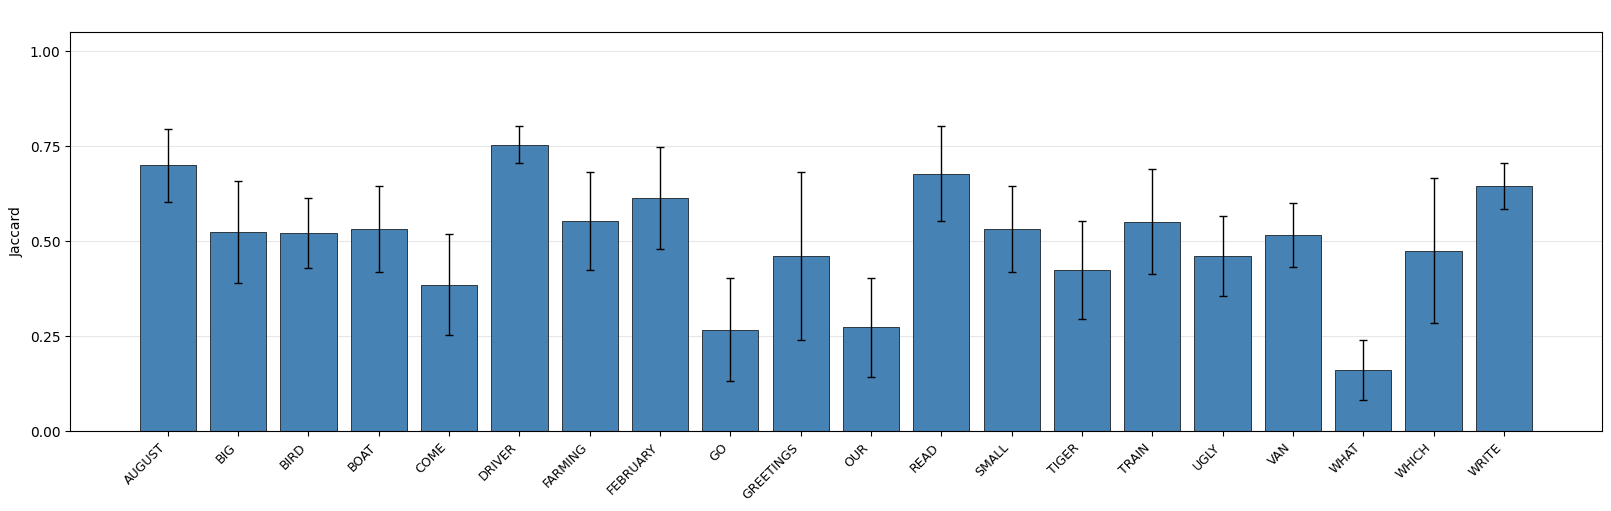

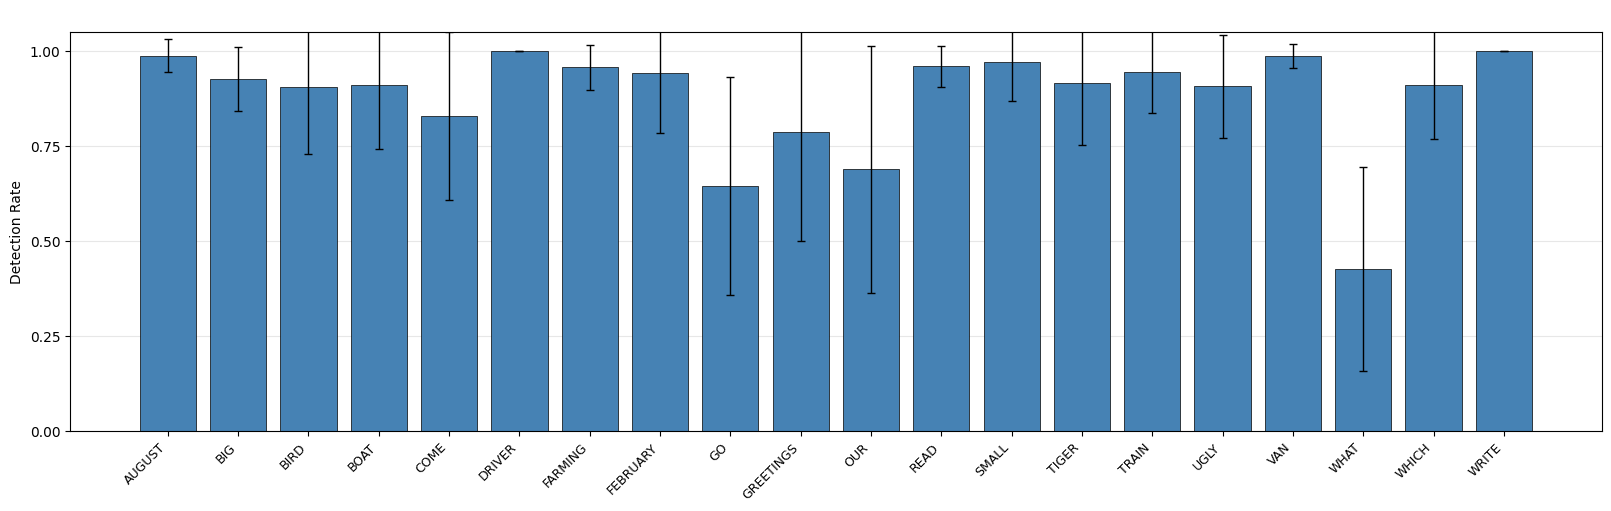

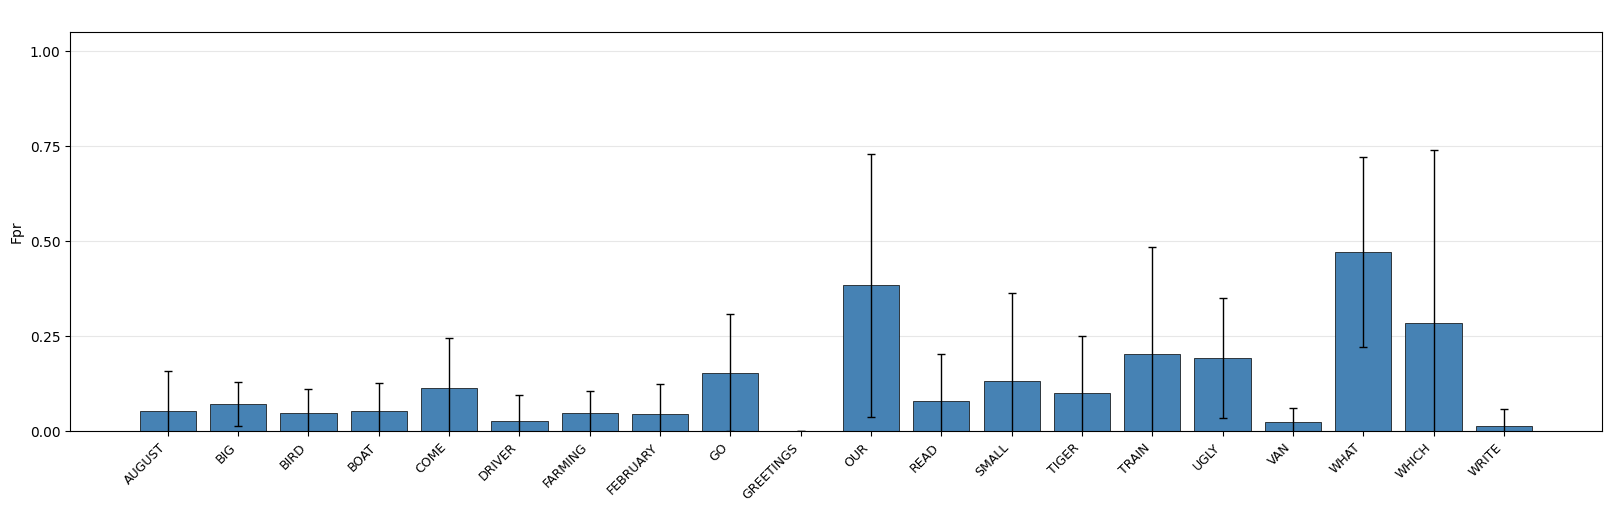

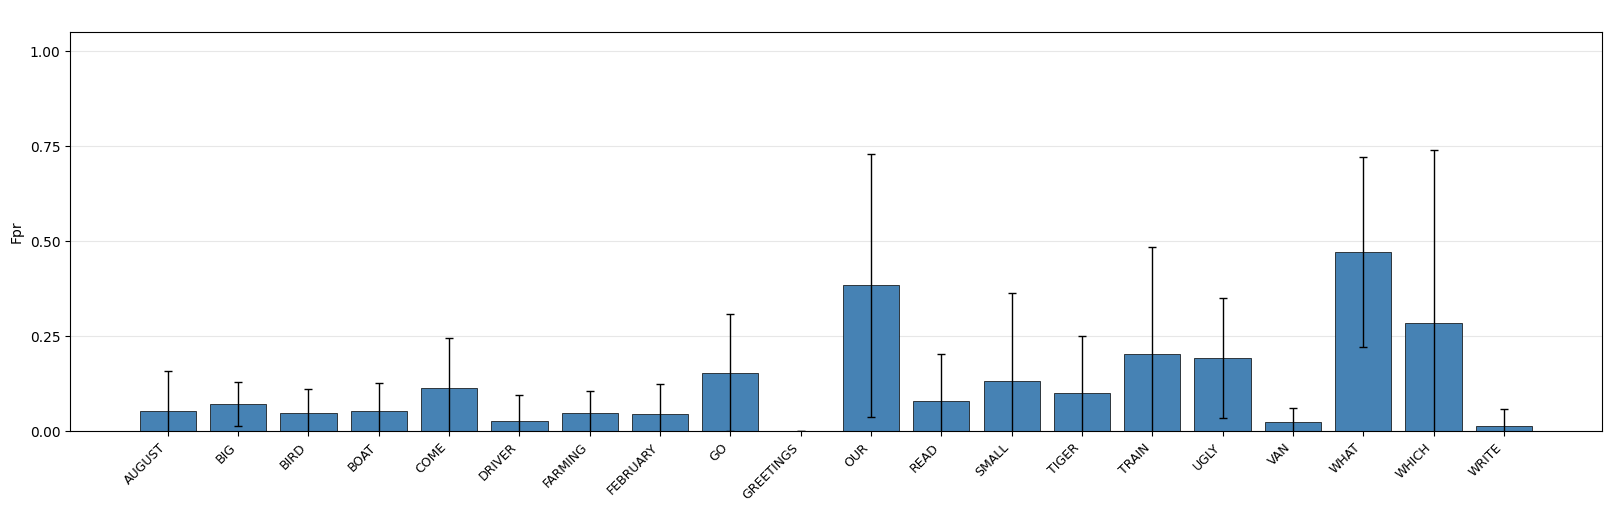

In [39]:
plot_per_class_metric_bar("test", metric="jaccard", title=" ")
plot_per_class_metric_bar("test", metric="detection_rate", title=" ")
plot_per_class_metric_bar("test", metric="fpr", title=" ")


In [40]:
def get_per_class_stats(split_name: str, metric: str) -> pd.DataFrame:
    """
    Mean/std/count of `metric` for each class, computed across every (run, user)
    combination for the given split. `metric` must be one of the columns produced by
    add_derived_rates (detection_rate, misclass_rate, fpr, jaccard).
    """
    d = add_derived_rates(per_class_metrics_df[per_class_metrics_df["split"] == split_name])
    stats = (
        d.groupby("class")[metric]
        .agg(["mean", "std", "count"])
        .reset_index()
        .sort_values("class")
    )
    return stats


def plot_per_class_metric_bar(
    metric: str            = "jaccard",
    splits: tuple          = ("test", "val"),
    split_labels: dict     = {"test": "Test", "val": "Validation"},
    colors: dict           = {"test": "steelblue", "val": "darkorange"},
    title: str | None      = None,
    figsize: tuple         = (16, 5),
    ylim: tuple            = (0, 1.05),
    save_path: str | None  = None,
) -> plt.Figure:
    """
    Grouped per-class bar chart for one metric, comparing splits side by side.
    Bar = mean, error bar = std across (run, user) combinations for that split.
    """
    # Gather stats per split, aligned on the union of classes
    stats_by_split = {s: get_per_class_stats(s, metric).set_index("class") for s in splits}
    classes = sorted(set().union(*[st.index for st in stats_by_split.values()]))
    x = np.arange(len(classes))

    n_splits  = len(splits)
    bar_width = 0.8 / n_splits

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

    for i, s in enumerate(splits):
        st     = stats_by_split[s].reindex(classes)
        offset = (i - (n_splits - 1) / 2) * bar_width
        ax.bar(
            x + offset,
            st["mean"],
            width=bar_width,
            yerr=st["std"].fillna(0.0),
            capsize=2,
            color=colors.get(s, None),
            edgecolor="black",
            linewidth=0.5,
            error_kw=dict(ecolor="black", elinewidth=0.8),
            label=split_labels.get(s, s),
        )

    ax.set_xticks(x)
    ax.set_xticklabels(classes, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel(metric.replace("_", " ").title(), fontsize=10)
    ax.set_ylim(*ylim)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.25))

    n = max(int(st["count"].max()) for st in stats_by_split.values() if len(st))
    ax.set_title(
        title if title is not None
        else f"Per-class {metric.replace('_', ' ').title()} "
             f"(mean ± std across up to {n} run×user groups)",
        fontsize=12,
    )
    ax.legend(fontsize=9, framealpha=0.9)
    ax.grid(axis="y", alpha=0.3, zorder=0)
    ax.set_axisbelow(True)

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved -> {save_path}")
    else:
        plt.show()

    return fig

Saved -> per_class_dr.pdf
Saved -> per_class_fpr.pdf
Saved -> per_class_ji.pdf


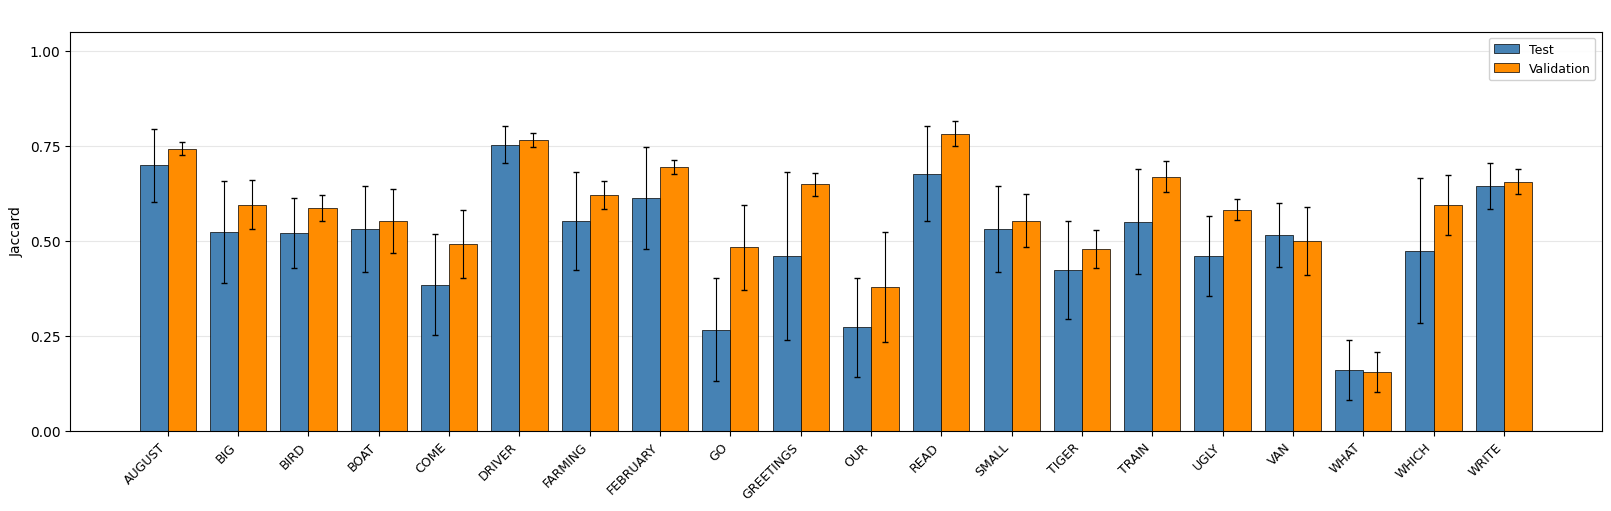

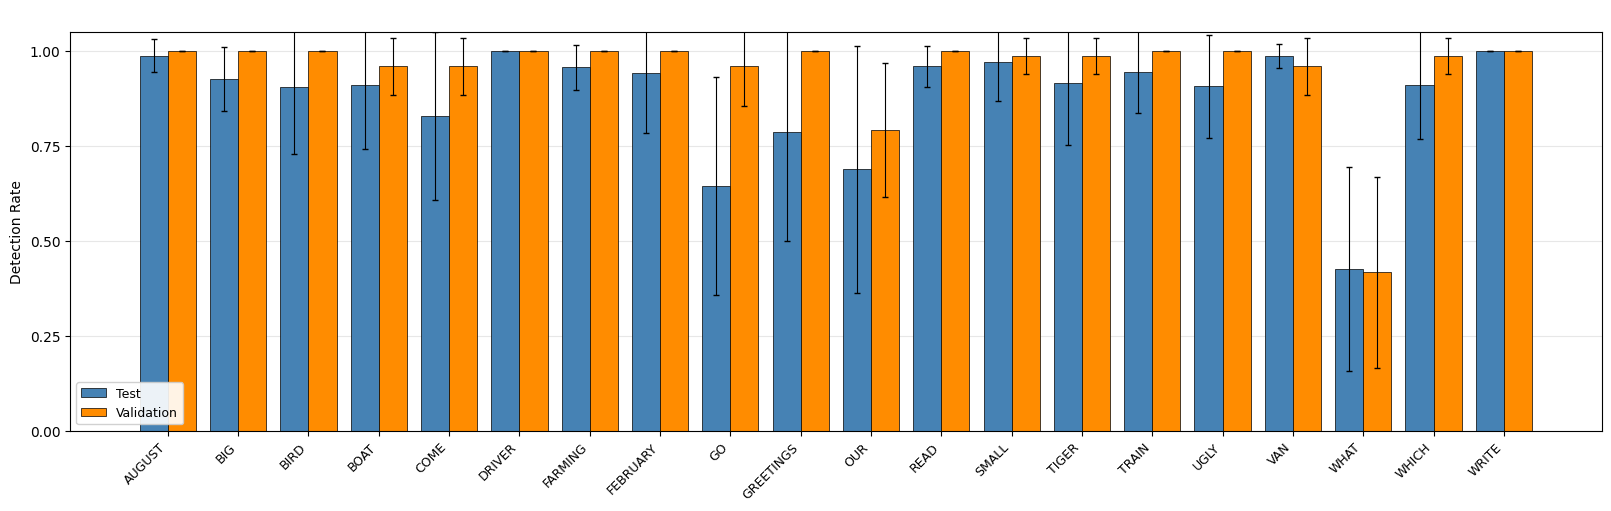

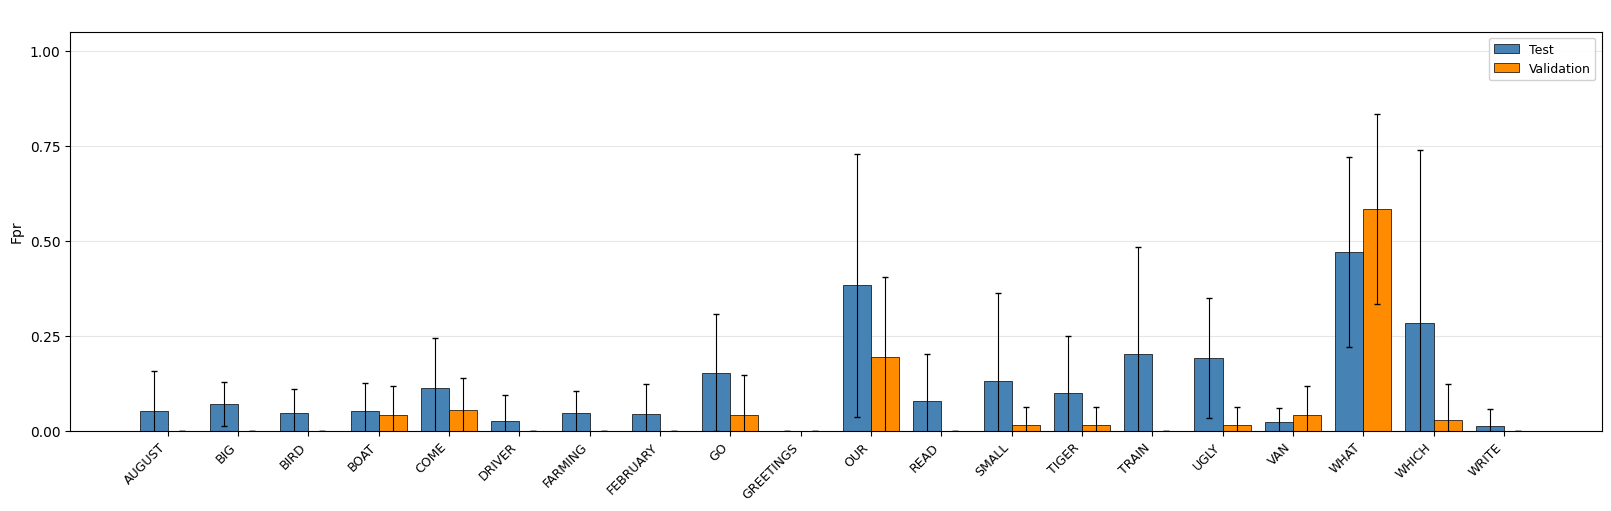

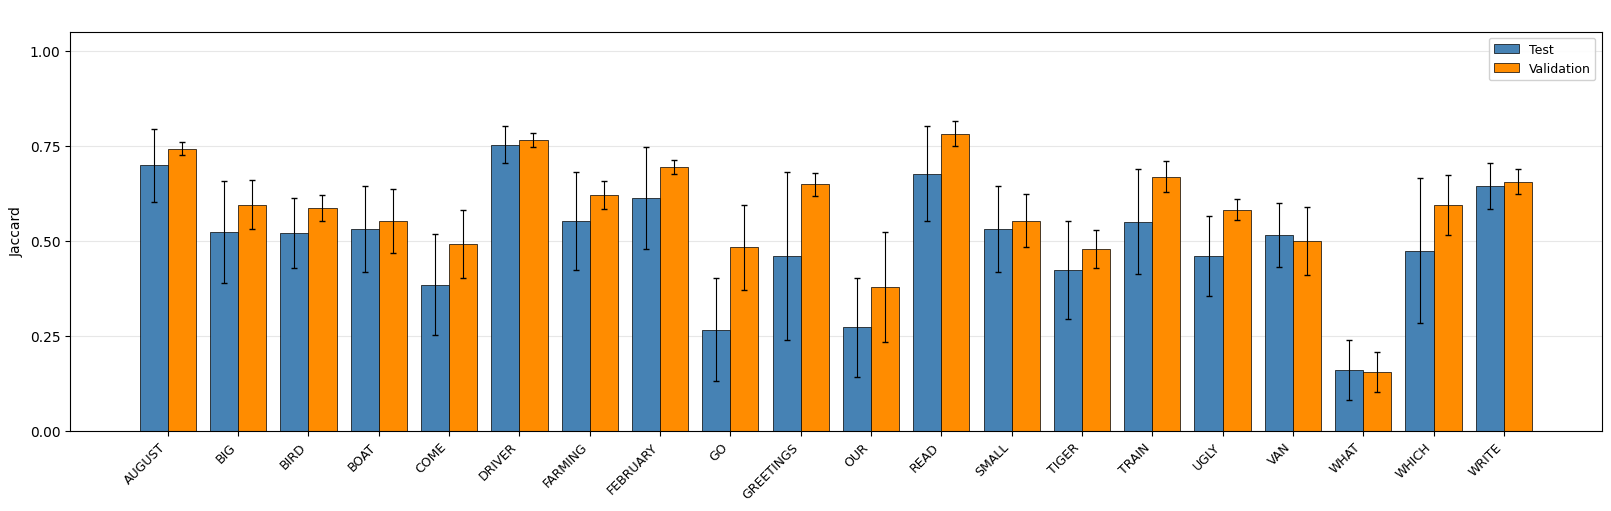

In [41]:
plot_per_class_metric_bar(metric="detection_rate", title=" ", save_path="per_class_dr.pdf")
plot_per_class_metric_bar(metric="fpr",            title=" ", save_path="per_class_fpr.pdf")
plot_per_class_metric_bar(metric="jaccard",        title=" ", save_path="per_class_ji.pdf")

In [42]:
def get_per_user_wer_stats(wer_df: pd.DataFrame) -> pd.DataFrame:
    """Mean/std/count of WER per (user, split) across all sequences."""
    return (
        wer_df.groupby(["user", "split"])["replayed_wer"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )


def plot_per_user_wer_bar(
    wer_df: pd.DataFrame,
    splits: tuple          = ("test", "val"),
    split_labels: dict     = {"test": "Test", "val": "Val"},
    colors: dict           = {"test": "#3B6BA5", "val": "#E07B39"},
    user_labels: dict | None = None,   # e.g. {"user1": "User 1", ...}
    title: str | None      = None,
    figsize: tuple         = (8, 5),
    ylim: tuple            = (0, None),
    save_path: str | None  = None,
    annotate: bool         = True,
) -> plt.Figure:
    """
    Grouped per-user WER bar chart (Test vs Val), in %.
    Bar = mean, error bar = std across sequences for that user/split.
    """
    stats = get_per_user_wer_stats(wer_df)
    users = sorted(stats["user"].unique())
    x = np.arange(len(users))

    n_splits  = len(splits)
    bar_width = 0.8 / n_splits

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

    for i, s in enumerate(splits):
        st = (
            stats[stats["split"] == s]
            .set_index("user")
            .reindex(users)
        )
        mean = st["mean"] * 100
        std  = st["std"].fillna(0.0) * 100
        offset = (i - (n_splits - 1) / 2) * bar_width

        bars = ax.bar(
            x + offset, mean, width=bar_width,
            yerr=std, capsize=3,
            color=colors.get(s), edgecolor="black", linewidth=0.5,
            error_kw=dict(ecolor="black", elinewidth=0.9),
            label=split_labels.get(s, s),
        )

        if annotate:
            for xi, m, sd in zip(x + offset, mean, std):
                if np.isnan(m):
                    continue
                ax.annotate(
                    f"{m:.2f}",
                    xy=(xi, m + sd),            # place above the error-bar cap
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", va="bottom", fontsize=8,
                )

    if user_labels is None:
        user_labels = {u: str(u).replace("user", "User ").strip() for u in users}
    ax.set_xticks(x)
    ax.set_xticklabels([user_labels.get(u, u) for u in users], fontsize=10)
    ax.set_ylabel("WER (%)", fontsize=10)
    ax.set_ylim(*ylim)
    if title:
        ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9, framealpha=0.9)
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.set_axisbelow(True)

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved -> {save_path}")
    else:
        plt.show()

    return fig

Saved -> metric_WER.pdf


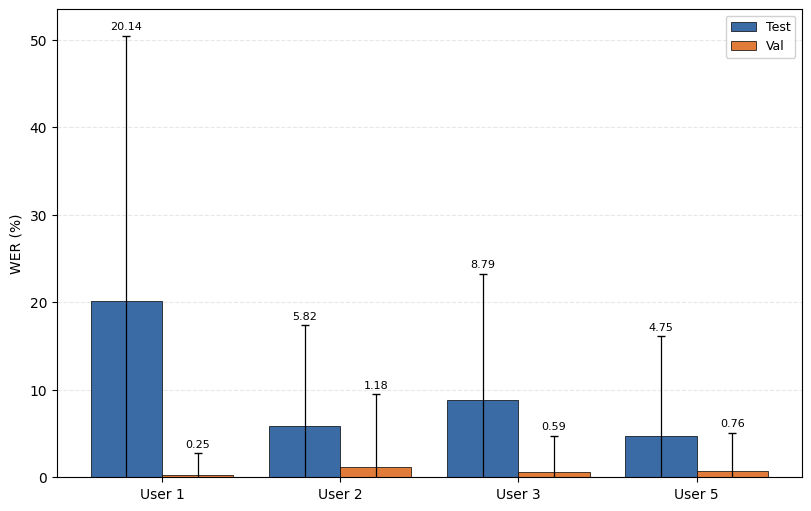

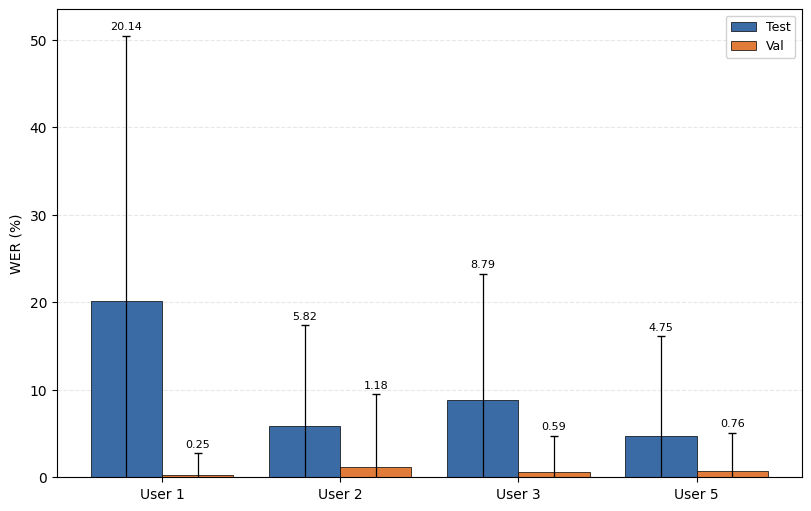

In [43]:
plot_per_user_wer_bar(per_sequence_wer_df, save_path="metric_WER.pdf")

---
## Next step

`per_class_metrics_df` (raw counts, per run/user/class) and `per_sequence_wer_df` (per run/user/recording) are the two reusable tables. Nothing is written to disk yet — tell me where/how you'd like them persisted (CSV, parquet, which directory) once you've decided how they'll be consumed downstream.

In [44]:
per_sequence_wer_df

,run,user,split,recording_id,stored_wer,replayed_wer,diff
0,seed42,user1,test,P1_S7_R5,0.00,0.00,0.0
1,seed42,user1,test,P1_S10_R1,0.00,0.00,0.0
2,seed42,user1,test,P1_S2_R5,0.00,0.00,0.0
3,seed42,user1,test,P1_S3_R1,0.25,0.25,0.0
4,seed42,user1,test,P1_S2_R4,0.00,0.00,0.0
...,...,...,...,...,...,...,...
1219,seed44,user5,val,P3_S7_R5,0.00,0.00,0.0
1220,seed44,user5,val,P3_S6_R2,0.00,0.00,0.0
1221,seed44,user5,val,P3_S5_R4,0.00,0.00,0.0
1222,seed44,user5,val,P3_S8_R3,0.00,0.00,0.0
